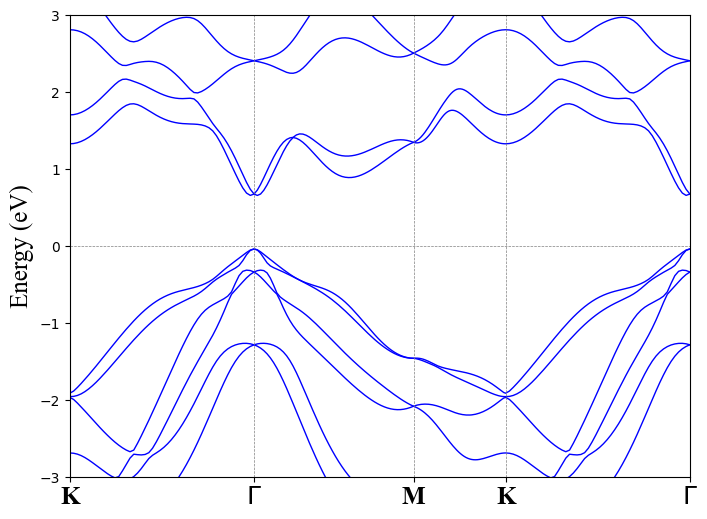

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data_band = np.loadtxt('REFORMATTED_BAND.dat')

k = data_band[:,0]
E = data_band[:,1:]


high_symmetry_points = [0,1.040,1.941,2.461,3.501]  
labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

plt.figure(figsize=(8, 6))
for i in range(E.shape[1]):
    plt.plot(k, E[:, i], color='blue',lw=1)
#plt.plot(k, E[:, 20], color='red', lw=1.5, label='Valence Band')
for i in range(len(high_symmetry_points)):
    plt.axvline(x=high_symmetry_points[i], color='gray', linestyle='--', lw=0.5)

plt.axhline(y=0, color='gray', linestyle='--', lw=0.5)    

plt.xticks(high_symmetry_points, labels,fontsize=18,fontname="Times New Roman", fontweight="bold")
plt.ylabel('Energy (eV)',fontsize=18,fontname="Times New Roman")
#plt.title('Band Structure of BiSb monolayer')
plt.xlim(min(k), max(k))
plt.ylim(-3, 3)
plt.savefig('BiAs_band_structure.png', dpi=300)
plt.show() 


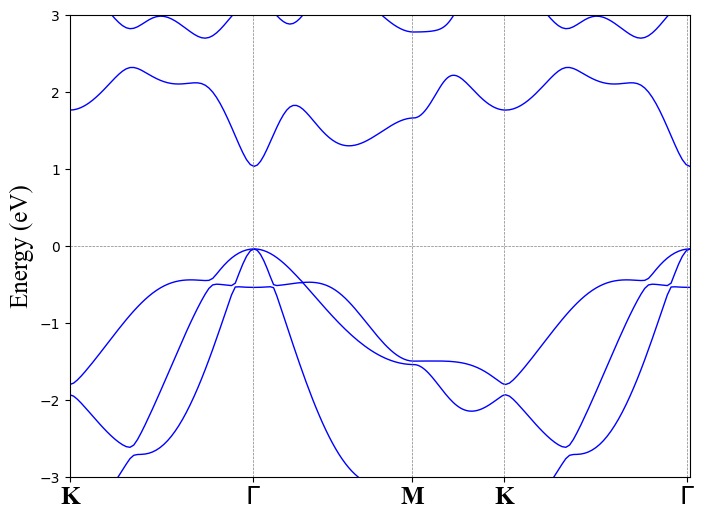

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data_band = np.loadtxt('wosoc-REFORMATTED_BAND.dat')

k = data_band[:,0]
E = data_band[:,1:]


high_symmetry_points = [0,1.040,1.941,2.461,3.501]  
labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

plt.figure(figsize=(8, 6))
for i in range(E.shape[1]):
    plt.plot(k, E[:, i], color='blue',lw=1)
#plt.plot(k, E[:, 20], color='red', lw=1.5, label='Valence Band')
for i in range(len(high_symmetry_points)):
    plt.axvline(x=high_symmetry_points[i], color='gray', linestyle='--', lw=0.5)

plt.axhline(y=0, color='gray', linestyle='--', lw=0.5)    

plt.xticks(high_symmetry_points, labels,fontsize=18,fontname="Times New Roman", fontweight="bold")
plt.ylabel('Energy (eV)',fontsize=18,fontname="Times New Roman")
#plt.title('Band Structure of BiSb monolayer')
plt.xlim(min(k), max(k))
plt.ylim(-3, 3)
plt.savefig('BiAs_band_structure.png', dpi=300)
plt.show() 


C:\Users\furka\AppData\Local\Temp\ipykernel_9360\1455568408.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_bi = pd.read_csv(r"PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
C:\Users\furka\AppData\Local\Temp\ipykernel_9360\1455568408.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_sb = pd.read_csv(r"PBAND_As_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


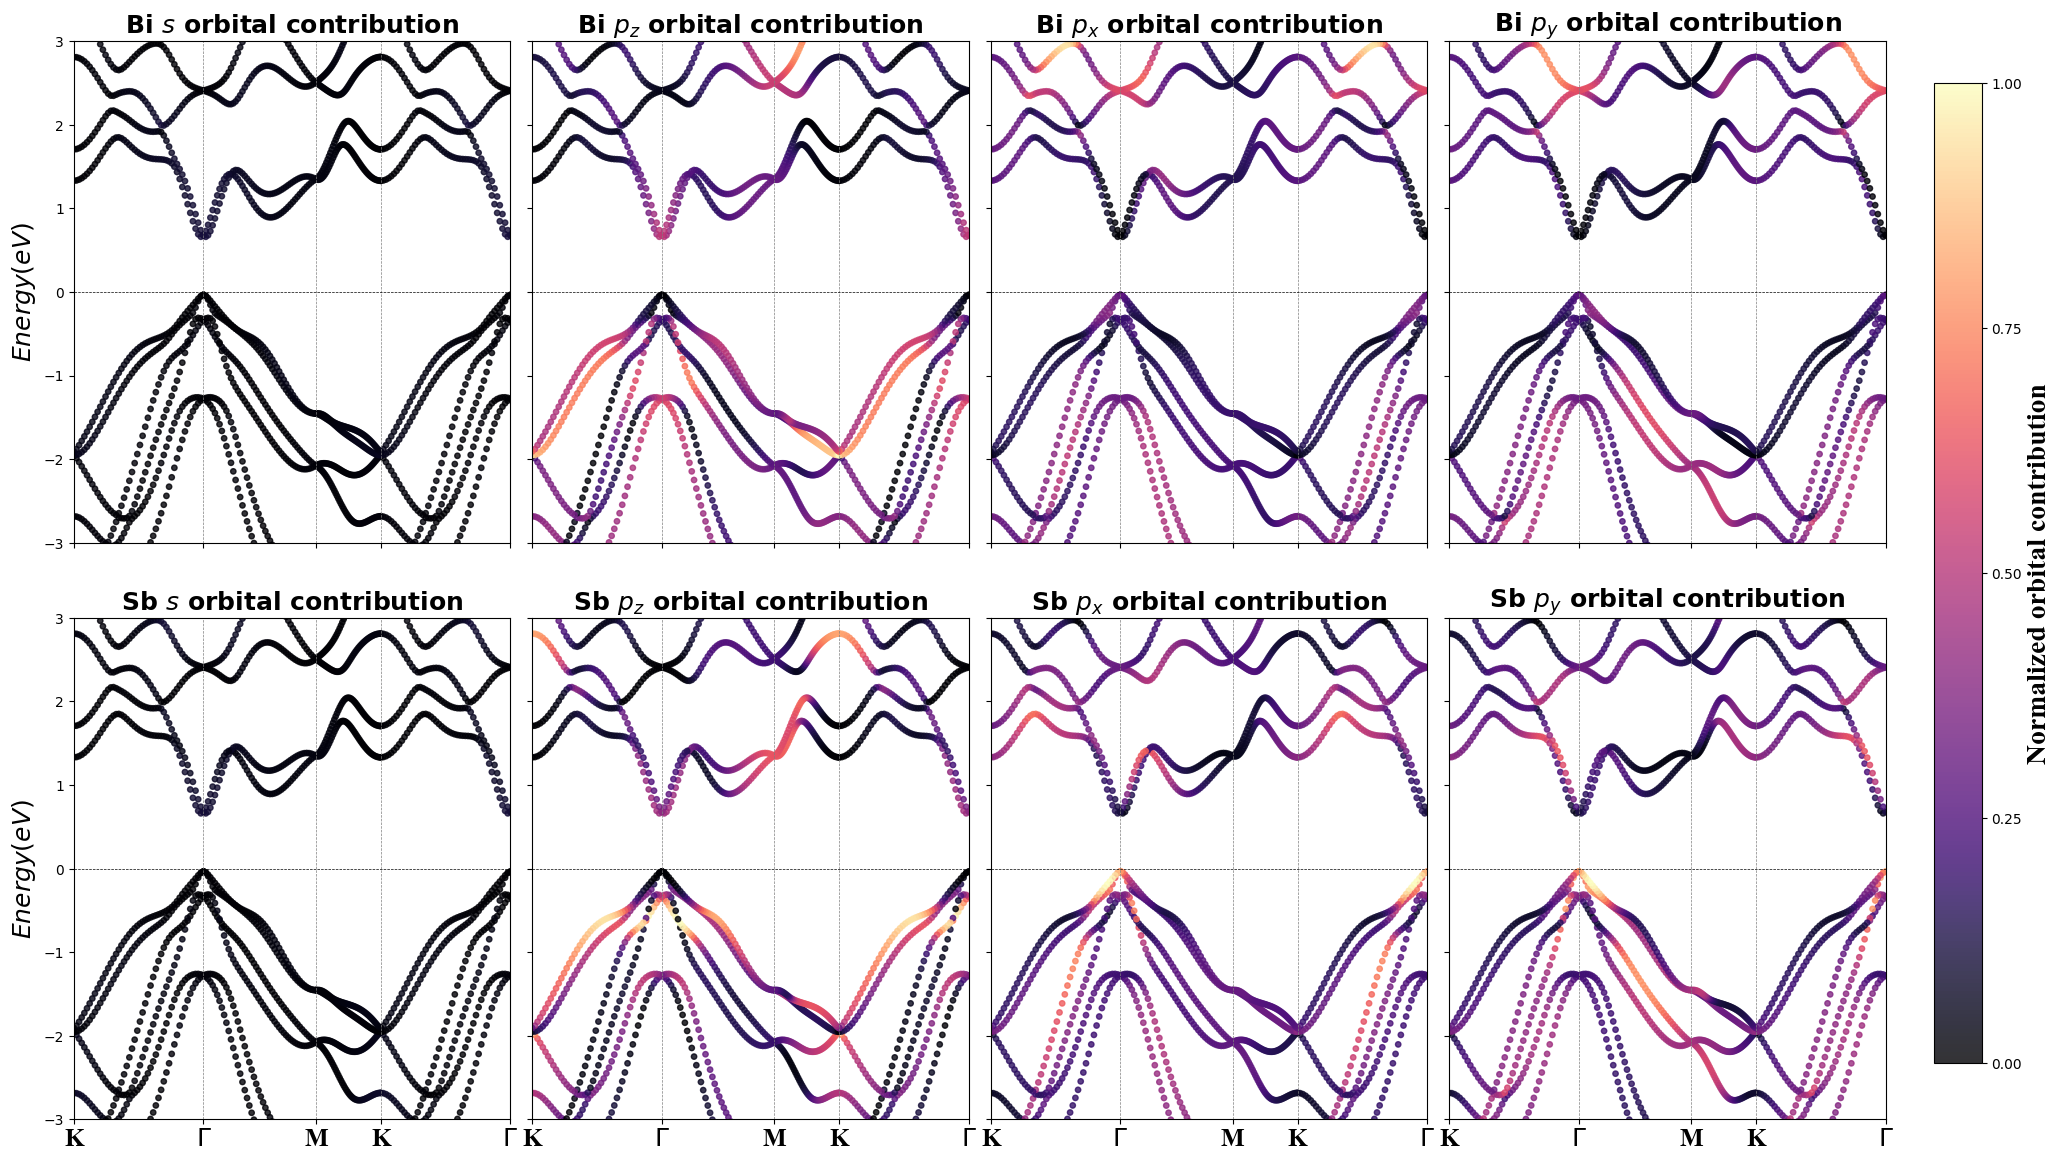

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Load data for both atoms ---
data_bi = pd.read_csv(r"PBAND_Bi_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
data_sb = pd.read_csv(r"PBAND_As_SOC.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)

k = np.array(data_bi[0])
e = np.array(data_bi[1])

# --- Extract raw values ---
bi_vals = [data_bi[i].values.astype(float) for i in range(2, 6)]  # s, px, py, pz
sb_vals = [data_sb[i].values.astype(float) for i in range(2, 6)]

# --- Normalize each orbital INDEPENDENTLY to [0, 1] ---
def local_norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

bi_norms = [local_norm(v) for v in bi_vals]
sb_norms = [local_norm(v) for v in sb_vals]


orbitals = [bi_norms[0],bi_norms[2], bi_norms[3], bi_norms[1],
            sb_norms[0],sb_norms[2], sb_norms[3], sb_norms[1]] 

names = ['Bi $s$', 'Bi $p_z$', 'Bi $p_x$', 'Bi $p_y$',
         'Sb $s$',  'Sb $p_z$', 'Sb $p_x$', 'Sb $p_y$']

cmap     = 'magma'

high_symmetry_points = [0,1.040,1.941,2.461,3.501]  
high_symmetry_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

fig, axes = plt.subplots(2, 4, figsize=(24, 14), sharex=True, sharey=True)
fig.subplots_adjust(right=0.88, hspace=0.15, wspace=0.05)
axes = axes.flatten()

last_scatter = None

for idx, (orbital, name) in enumerate(zip(orbitals, names)):
    ax = axes[idx]

    scatter = ax.scatter(
        k, e,
        c=orbital,
        s=15, cmap=cmap, alpha=0.8,
        vmin=0, vmax=1
    )
    last_scatter = scatter

    ax.set_title(f'{name} orbital contribution', fontsize=18, fontweight='bold')
    ax.set_ylim(-3, 3)
    ax.set_xlim(min(k), max(k))

    for x in high_symmetry_points:
        ax.axvline(x=x, color='gray', linestyle='--', lw=0.5)
    ax.axhline(0, ls='--', lw=0.5, color='black')

    # x-axis tick labels for all rows (since they share x-axis)
    ax.set_xticks(high_symmetry_points)
    ax.set_xticklabels(high_symmetry_labels,fontsize=18,fontname="Times New Roman", fontweight="bold")

    # y-axis label only on left column
    if idx % 4 == 0:
        ax.set_ylabel(r'$Energy (eV)$',fontsize=18,fontname="Times New Roman")

# --- Single global colorbar on the right ---
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(last_scatter, cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])
cbar.set_label('Normalized orbital contribution',fontsize=20,fontname="Times New Roman", fontweight="bold")
cbar.ax.tick_params(labelsize=10)
plt.savefig("bias_orbital_composed_bands.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\furka\AppData\Local\Temp\ipykernel_9360\792296929.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_bi = pd.read_csv(r"PBAND_Bi.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
C:\Users\furka\AppData\Local\Temp\ipykernel_9360\792296929.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_sb = pd.read_csv(r"PBAND_As.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)


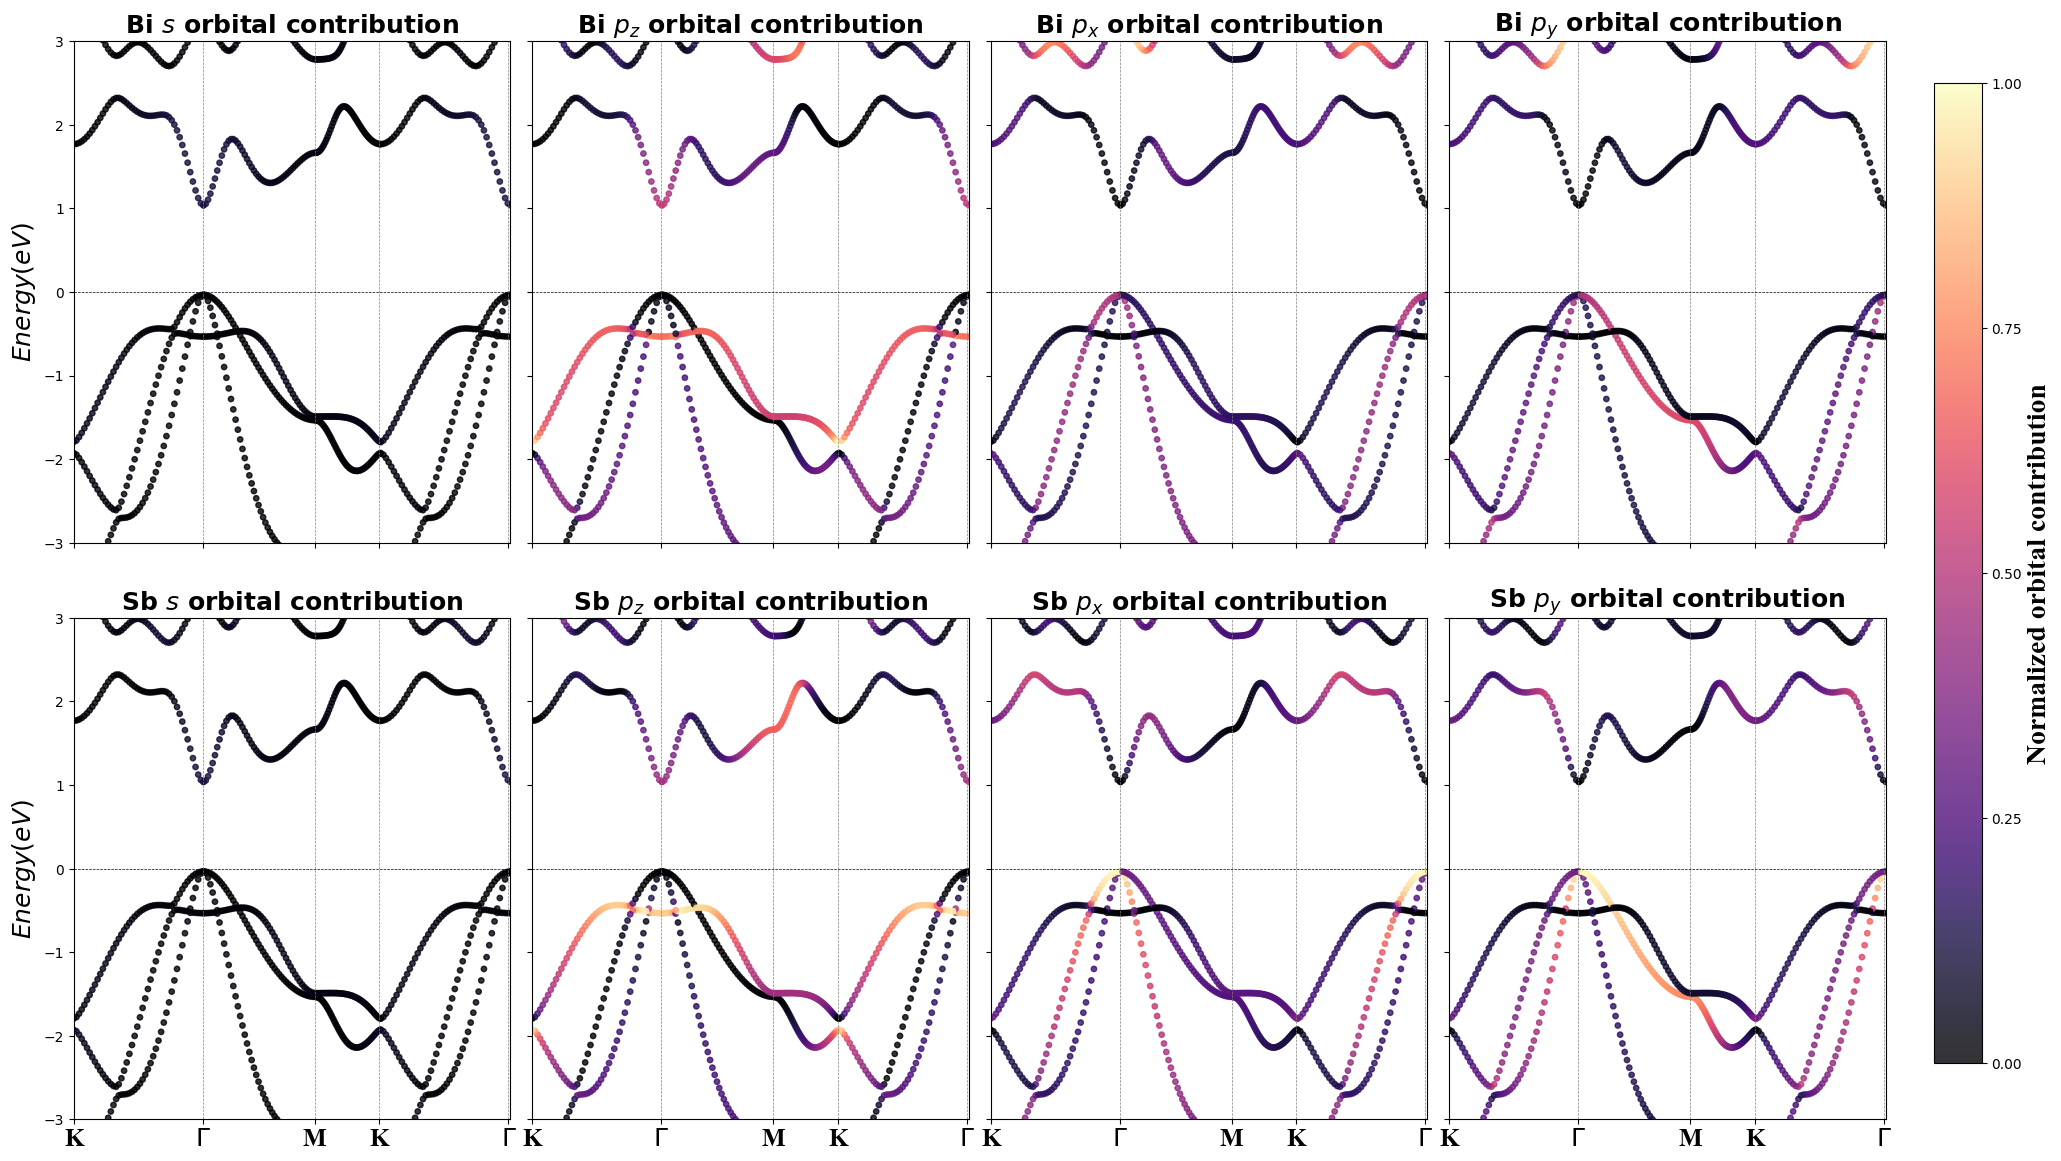

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Load data for both atoms ---
data_bi = pd.read_csv(r"PBAND_Bi.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)
data_sb = pd.read_csv(r"PBAND_As.dat", comment='#', delim_whitespace=True, header=None, skiprows=2)

k = np.array(data_bi[0])
e = np.array(data_bi[1])

# --- Extract raw values ---
bi_vals = [data_bi[i].values.astype(float) for i in range(2, 6)]  # s, px, py, pz
sb_vals = [data_sb[i].values.astype(float) for i in range(2, 6)]

# --- Normalize each orbital INDEPENDENTLY to [0, 1] ---
def local_norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

bi_norms = [local_norm(v) for v in bi_vals]
sb_norms = [local_norm(v) for v in sb_vals]


orbitals = [bi_norms[0],bi_norms[2], bi_norms[3], bi_norms[1],
            sb_norms[0],sb_norms[2], sb_norms[3], sb_norms[1]] 

names = ['Bi $s$', 'Bi $p_z$', 'Bi $p_x$', 'Bi $p_y$',
         'Sb $s$',  'Sb $p_z$', 'Sb $p_x$', 'Sb $p_y$']

cmap     = 'magma'

high_symmetry_points = [0,1.040,1.941,2.461,3.501]  
high_symmetry_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

fig, axes = plt.subplots(2, 4, figsize=(24, 14), sharex=True, sharey=True)
fig.subplots_adjust(right=0.88, hspace=0.15, wspace=0.05)
axes = axes.flatten()

last_scatter = None

for idx, (orbital, name) in enumerate(zip(orbitals, names)):
    ax = axes[idx]

    scatter = ax.scatter(
        k, e,
        c=orbital,
        s=15, cmap=cmap, alpha=0.8,
        vmin=0, vmax=1
    )
    last_scatter = scatter

    ax.set_title(f'{name} orbital contribution', fontsize=18, fontweight='bold')
    ax.set_ylim(-3, 3)
    ax.set_xlim(min(k), max(k))

    for x in high_symmetry_points:
        ax.axvline(x=x, color='gray', linestyle='--', lw=0.5)
    ax.axhline(0, ls='--', lw=0.5, color='black')

    # x-axis tick labels for all rows (since they share x-axis)
    ax.set_xticks(high_symmetry_points)
    ax.set_xticklabels(high_symmetry_labels,fontsize=18,fontname="Times New Roman", fontweight="bold")

    # y-axis label only on left column
    if idx % 4 == 0:
        ax.set_ylabel(r'$Energy (eV)$',fontsize=18,fontname="Times New Roman")

# --- Single global colorbar on the right ---
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(last_scatter, cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])
cbar.set_label('Normalized orbital contribution',fontsize=20,fontname="Times New Roman", fontweight="bold")
cbar.ax.tick_params(labelsize=10)
plt.savefig("bias_orbital_composed_bands.png", dpi=150, bbox_inches="tight")
plt.show()

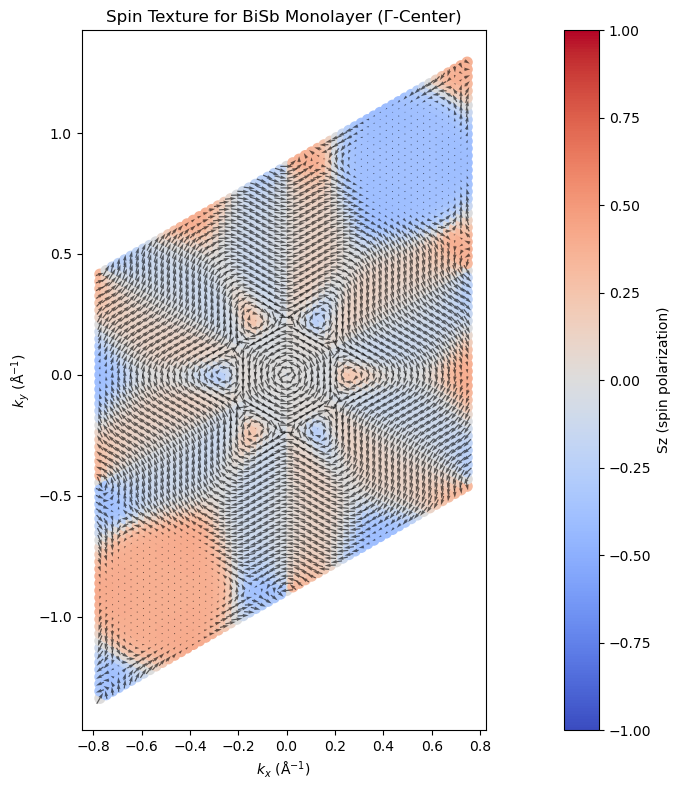

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
def plot_spin_texture(data_file):
    data_spin = np.loadtxt(
    data_file,
    comments="#",
    usecols=(0, 1, 3, 4, 5),
)
    kx = data_spin[:, 0]
    ky = data_spin[:, 1]
    Sx = data_spin[:, 2]
    Sy = data_spin[:, 3]
    Sz = data_spin[:, 4]

    fig, ax = plt.subplots(figsize=(16, 8))

    # Background: scatter colored by Sz
    norm = Normalize(vmin=-1, vmax=1)
    sc = ax.scatter(kx, ky, c=Sz, cmap="coolwarm", norm=norm, s=50, zorder=1)
    fig.colorbar(sc, ax=ax, label="Sz (spin polarization)")

    # Foreground: quiver arrows showing in-plane spin (Sx, Sy)
    ax.quiver(kx, ky, Sx, Sy,
            pivot="mid",
            scale=8,          # lower = longer arrows; tune to your grid
            scale_units="xy",
            width=0.003,
            color="black",
            alpha=0.6,
            zorder=2)

    ax.set_xlabel(r"$k_x$ (Å$^{-1}$)")
    ax.set_ylabel(r"$k_y$ (Å$^{-1}$)")
    ax.set_title("Spin Texture for BiSb Monolayer (Γ-Center)")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()
plot_spin_texture("31-SPINTEXTURE_2D_GAMMA_CENTER.dat")    

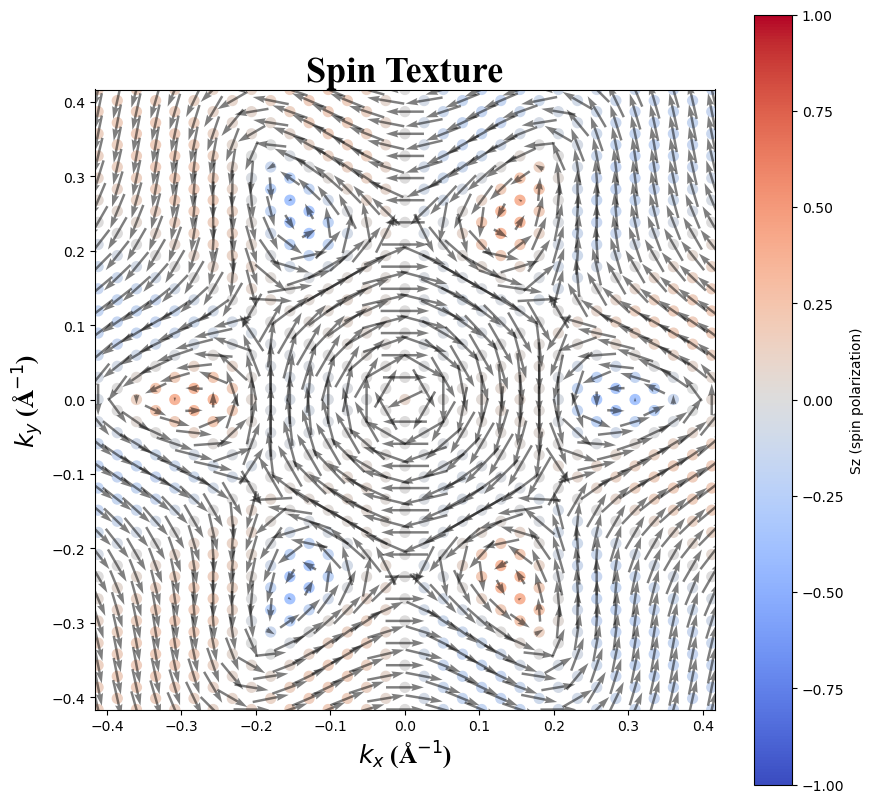

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

data_spin = np.loadtxt(
    "32-SPINTEXTURE_2D_GAMMA_CENTER.dat",
    comments="#",
    usecols=(0, 1, 3, 4, 5),
)
kx = data_spin[:, 0]
ky = data_spin[:, 1]
Sx = data_spin[:, 2]
Sy = data_spin[:, 3]
Sz = data_spin[:, 4]

# ── Crop to the largest square fully covered by data ─────────────────────────
kx_unique = np.unique(kx)
ky_unique = np.unique(ky)

# For each ky row, find the kx extent; take the tightest (inner square)
kx_min_per_ky = [kx[ky == y].min() for y in ky_unique]
kx_max_per_ky = [kx[ky == y].max() for y in ky_unique]
kx_lo = np.max(kx_min_per_ky)
kx_hi = np.min(kx_max_per_ky)

# For each kx column, find the ky extent; take the tightest
ky_min_per_kx = [ky[kx == x].min() for x in kx_unique]
ky_max_per_kx = [ky[kx == x].max() for x in kx_unique]
ky_lo = np.max(ky_min_per_kx)
ky_hi = np.min(ky_max_per_kx)

# Use the tightest bound across both axes to guarantee no empty corners
k_sq = min(abs(kx_lo), abs(kx_hi), abs(ky_lo), abs(ky_hi))

mask = (np.abs(kx) <= k_sq) & (np.abs(ky) <= k_sq)

kx_p, ky_p = kx[mask], ky[mask]
Sx_p, Sy_p, Sz_p = Sx[mask], Sy[mask], Sz[mask]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

norm = Normalize(vmin=-1, vmax=1)
sc = ax.scatter(kx_p, ky_p, c=Sz_p, cmap="coolwarm", norm=norm, s=50, zorder=1)
fig.colorbar(sc, ax=ax, label="Sz (spin polarization)")

ax.quiver(kx_p, ky_p, Sx_p, Sy_p,
          pivot="mid",
          scale=8,
          scale_units="xy",
          width=0.004,
          color="black",
          alpha=0.5,
          zorder=2)

ax.set_xlim(-k_sq, k_sq)
ax.set_ylim(-k_sq, k_sq)
ax.set_xlabel(r"$k_x$ (Å$^{-1}$)",fontsize=18,fontname="Times New Roman", fontweight="bold")
ax.set_ylabel(r"$k_y$ (Å$^{-1}$)",fontsize=18,fontname="Times New Roman", fontweight="bold")
ax.set_title("Spin Texture",fontsize=26,fontname="Times New Roman", fontweight="bold")
ax.set_aspect("equal")


plt.savefig("spin_texture.png", dpi=150, bbox_inches="tight")
plt.show()


Dataset 1: 834 points kept (out of 3600) in window [-2.3500, -2.0500] eV
Dataset 2: 144 points kept (out of 3600) in window [-2.3500, -2.0500] eV


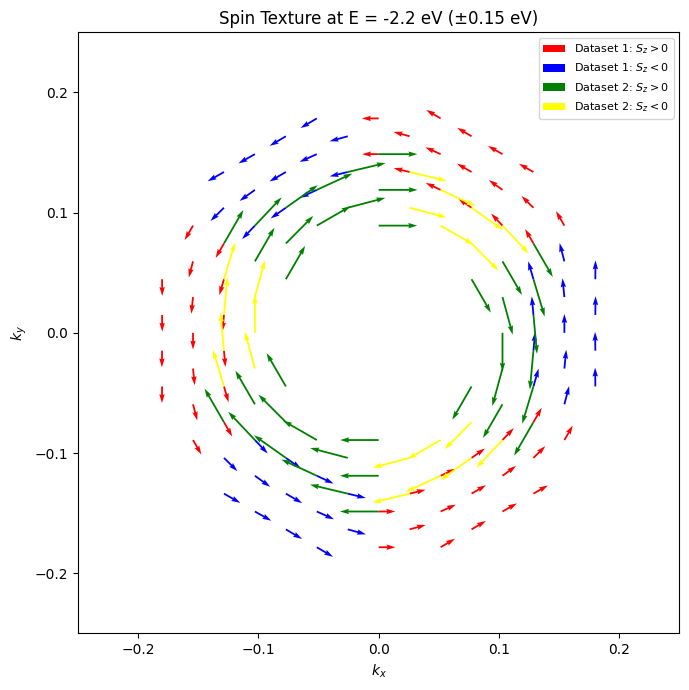

In [31]:
"""
Spin texture plotter for two datasets (e.g., two W-shaped bands above E_F).

Each data file must be plain text / whitespace- or comma-separated with 6 columns:
    k_x   k_y   E   S_x   S_y   S_z

Workflow:
    1. Load both datasets.
    2. Mask each dataset to keep only points with E in [E0 - dE, E0 + dE].
    3. Plot in-plane spin texture (S_x, S_y) as quiver arrows, colored by the
       SIGN of S_z only (two colors: one for S_z > 0, one for S_z < 0).

Edit the CONFIG block below to point to your files and set E0 / dE.
"""

import numpy as np
import matplotlib.pyplot as plt

# =========================== CONFIG ===========================
# Path to your two data files
DATA_FILE_1 = "31-SPINTEXTURE_2D_GAMMA_CENTER.dat"
DATA_FILE_2 = "32-SPINTEXTURE_2D_GAMMA_CENTER.dat"

# Energy window: keep points with E0 - dE <= E <= E0 + dE
E0 = -2.2      # basis energy (eV), e.g. 50 meV above E_F
dE = 0.15      # half-width of energy window (eV)

# Column indices (0-indexed) in the data files: kx, ky, E, Sx, Sy, Sz
COLS = dict(kx=0, ky=1, E=2, Sx=3, Sy=4, Sz=5)

# Colors for S_z sign
COLOR_SZ_POS = "red"
COLOR_SZ_NEG = "blue"

COLOR_SZ_POS_2 = "green"
COLOR_SZ_NEG_2 = "yellow"

# Quiver appearance
ARROW_SCALE = None      # None = matplotlib auto-scales; set a number to fix arrow length
ARROW_WIDTH = 0.003

# Titles for the two subplots
TITLE_1 = "Dataset 1"
TITLE_2 = "Dataset 2"

ALPHA_1 = 1.0
ALPHA_2 = 1.0
 
# Labels for the two datasets (used in the legend)
LABEL_1 = "Dataset 1"
LABEL_2 = "Dataset 2"

TITLE = "Spin Texture"

# Output figure filename
OUTPUT_FIGURE = "spin_texture.png"
# ================================================================
def load_data(filepath):
    """Load a whitespace/comma-separated 6-column data file."""
    data = np.loadtxt(filepath, delimiter=None)
    return {
        "kx": data[:, COLS["kx"]],
        "ky": data[:, COLS["ky"]],
        "E": data[:, COLS["E"]],
        "Sx": data[:, COLS["Sx"]],
        "Sy": data[:, COLS["Sy"]],
        "Sz": data[:, COLS["Sz"]],
    }
 
 
def mask_energy_window(d, E0, dE):
    """Return only the entries with E in [E0 - dE, E0 + dE]."""
    mask = (d["E"] >= E0 - dE) & (d["E"] <= E0 + dE)
    return {key: val[mask] for key, val in d.items()}
 
 
def plot_spin_texture(ax, d, label_prefix, color_pos, color_neg):
    """Quiver plot of (Sx, Sy) colored by sign of Sz, on the given axis."""
    pos = d["Sz"] >= 0
    neg = ~pos
 
    ax.quiver(
        d["kx"][pos], d["ky"][pos], d["Sx"][pos], d["Sy"][pos],
        color=color_pos, scale=ARROW_SCALE, width=ARROW_WIDTH,
        label=f"{label_prefix}: $S_z > 0$",
    )
    ax.quiver(
        d["kx"][neg], d["ky"][neg], d["Sx"][neg], d["Sy"][neg],
        color=color_neg, scale=ARROW_SCALE, width=ARROW_WIDTH,
        label=f"{label_prefix}: $S_z < 0$",
    )
 
 
def main():
    d1 = load_data(DATA_FILE_1)
    d2 = load_data(DATA_FILE_2)
 
    d1_masked = mask_energy_window(d1, E0, dE)
    d2_masked = mask_energy_window(d2, E0, dE)
 
    print(f"Dataset 1: {len(d1_masked['E'])} points kept "
          f"(out of {len(d1['E'])}) in window [{E0-dE:.4f}, {E0+dE:.4f}] eV")
    print(f"Dataset 2: {len(d2_masked['E'])} points kept "
          f"(out of {len(d2['E'])}) in window [{E0-dE:.4f}, {E0+dE:.4f}] eV")
 
    fig, ax = plt.subplots(figsize=(7, 7))
 
    plot_spin_texture(ax, d1_masked, LABEL_1, COLOR_SZ_POS,COLOR_SZ_NEG)
    plot_spin_texture(ax, d2_masked, LABEL_2, COLOR_SZ_POS_2,COLOR_SZ_NEG_2)
 
    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_xlim(-0.25,0.25)
    ax.set_ylim(-0.25,0.25)
    ax.set_title(f"{TITLE} at E = {E0} eV (±{dE} eV)")
    fig.tight_layout()
    #fig.savefig(OUTPUT_FIGURE, dpi=300)
    plt.show()
 
 
if __name__ == "__main__":
    main()

Dataset 1: 402 points kept (out of 3600) in window [-2.4000, -2.2000] eV
Dataset 2: 36 points kept (out of 3600) in window [-2.4000, -2.2000] eV
Dataset 1: circle radius = 0.50103, 138/402 points kept (tol = 0.05)
Dataset 2: circle radius = 0.09398, 36/36 points kept (tol = 0.05)
Dataset 1: mean(k x S)_z = -1.864e-01 -> CW (0% of points positive)
Dataset 2: mean(k x S)_z = -4.877e-02 -> CW (0% of points positive)


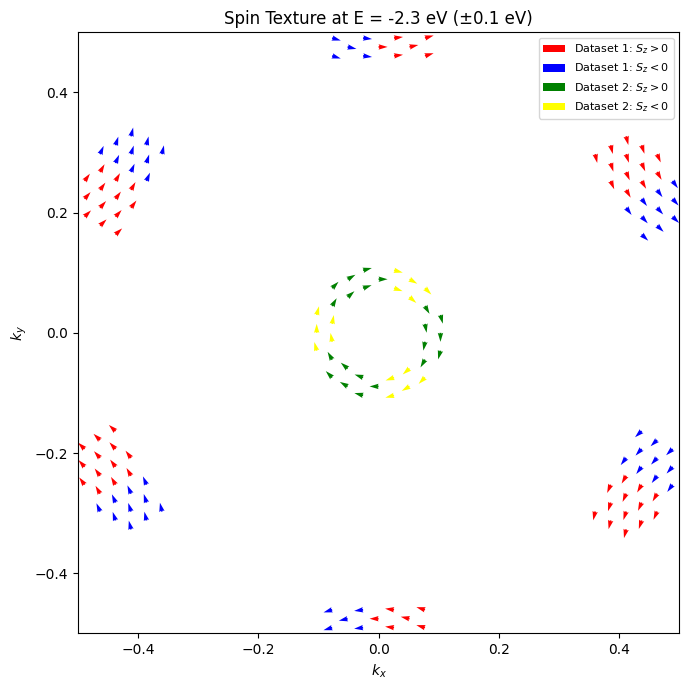

In [29]:
"""
Spin texture plotter for two datasets (e.g., Rashba-split bands above/below E_F).

Each data file must be plain text / whitespace- or comma-separated with 6 columns:
    k_x   k_y   E   S_x   S_y   S_z

Workflow:
    1. Load both datasets.
    2. Mask each dataset to keep only points with E in [E0 - dE, E0 + dE].
    3. From these energy-masked points, fit the "ideal" circle radius for each
       dataset separately (mean of sqrt(kx^2 + ky^2)), then keep only the
       points that actually lie close to that circle (within CIRCLE_TOL).
       This throws away the scattered/off-ring points that make the raw
       energy-window selection look messy or spiral-like, and keeps only
       the clean set of k-points that trace out the constant-energy ring.
    4. Plot the in-plane spin texture (S_x, S_y) as quiver arrows for the
       on-circle points only, on a single shared axis, colored by dataset
       AND by the sign of S_z (4 colors total). Arrow vectors are normalized
       to a fixed length so both datasets/rings are visually comparable
       regardless of their raw spin magnitudes or ring radius.

Edit the CONFIG block below to point to your files and set E0 / dE / CIRCLE_TOL.
"""

import numpy as np
import matplotlib.pyplot as plt

# =========================== CONFIG ===========================
# Path to your two data files
DATA_FILE_1 = "31-SPINTEXTURE_2D_GAMMA_CENTER.dat"
DATA_FILE_2 = "32-SPINTEXTURE_2D_GAMMA_CENTER.dat"

# Energy window: keep points with E0 - dE <= E <= E0 + dE
E0 = -2.3      # basis energy (eV)
dE = 0.1      # half-width of energy window (eV)

# Tolerance for keeping points close to each dataset's own fitted circle radius
# (points with | |k| - r_fit | > CIRCLE_TOL are discarded)
CIRCLE_TOL = 0.05

# Column indices (0-indexed) in the data files: kx, ky, E, Sx, Sy, Sz
COLS = dict(kx=0, ky=1, E=2, Sx=3, Sy=4, Sz=5)

# Colors: dataset 1 (Sz>0 / Sz<0) and dataset 2 (Sz>0 / Sz<0)
COLOR_SZ_POS_1 = "red"
COLOR_SZ_NEG_1 = "blue"
COLOR_SZ_POS_2 = "green"
COLOR_SZ_NEG_2 = "yellow"

# Normalized arrow length (all arrows rescaled to this length, in kx/ky units)
ARROW_LENGTH = 0.015
ARROW_WIDTH = 0.004

# Labels for the two datasets (used in the legend)
LABEL_1 = "Dataset 1"
LABEL_2 = "Dataset 2"

TITLE = "Spin Texture"

# Axis limits (set to None to auto-fit around both circles instead)
XLIM = (-0.5, 0.5)
YLIM = (-0.5, 0.5)

# Output figure filename
OUTPUT_FIGURE = "spin_texture.png"
# ================================================================


def load_data(filepath):
    """Load a whitespace/comma-separated 6-column data file."""
    data = np.loadtxt(filepath, delimiter=None)
    return {
        "kx": data[:, COLS["kx"]],
        "ky": data[:, COLS["ky"]],
        "E": data[:, COLS["E"]],
        "Sx": data[:, COLS["Sx"]],
        "Sy": data[:, COLS["Sy"]],
        "Sz": data[:, COLS["Sz"]],
    }


def mask_energy_window(d, E0, dE):
    """Return only the entries with E in [E0 - dE, E0 + dE]."""
    mask = (d["E"] >= E0 - dE) & (d["E"] <= E0 + dE)
    filtered = {key: val[mask] for key, val in d.items()}
    if len(filtered["E"]) == 0:
        raise ValueError(
            f"No points found in energy window [{E0-dE:.4f}, {E0+dE:.4f}] eV. "
            f"Data E range is [{d['E'].min():.4f}, {d['E'].max():.4f}] eV. "
            f"Adjust E0/dE."
        )
    return filtered


def fit_ideal_circle_radius(d):
    """Estimate the 'ideal' constant-energy circle radius as the mean |k|."""
    k_mag = np.sqrt(d["kx"] ** 2 + d["ky"] ** 2)
    return k_mag.mean(), k_mag.std()


def mask_to_circle(d, tol):
    """
    Given energy-window-masked data, fit this dataset's own ideal circle
    radius, then keep only the points whose |k| is within `tol` of that
    radius (i.e. the points that actually trace out the ring).

    Returns (filtered_data, radius).
    """
    r, _ = fit_ideal_circle_radius(d)
    k_mag = np.sqrt(d["kx"] ** 2 + d["ky"] ** 2)
    mask = np.abs(k_mag - r) <= tol
    filtered = {key: val[mask] for key, val in d.items()}
    if len(filtered["kx"]) == 0:
        raise ValueError(
            f"No points found within CIRCLE_TOL={tol} of fitted radius r={r:.5f}. "
            f"|k| range in this energy window is "
            f"[{k_mag.min():.5f}, {k_mag.max():.5f}]. Increase CIRCLE_TOL."
        )
    return filtered, r


def normalize_arrows(Sx, Sy, length):
    """Rescale (Sx, Sy) vectors to a fixed length, preserving direction."""
    mag = np.sqrt(Sx ** 2 + Sy ** 2)
    mag_safe = np.where(mag == 0, 1.0, mag)  # avoid division by zero
    Ux = (Sx / mag_safe) * length
    Uy = (Sy / mag_safe) * length
    return Ux, Uy


def chirality_index(d):
    """
    Quantitative check of the spin texture's rotation sense (chirality)
    relative to the radial direction, independent of arrow length/scaling.

    For each point, compute the z-component of k x S = kx*Sy - ky*Sx.
    Positive mean -> spins rotate counter-clockwise relative to k (CCW).
    Negative mean -> clockwise (CW).

    Returns (mean_cross, fraction_of_points_positive).
    """
    cross = d["kx"] * d["Sy"] - d["ky"] * d["Sx"]
    return cross.mean(), (cross > 0).mean()


def plot_spin_texture(ax, d, label_prefix, color_pos, color_neg):
    """Quiver plot of normalized (Sx, Sy), colored by sign of Sz."""
    pos = d["Sz"] >= 0
    neg = ~pos

    Ux, Uy = normalize_arrows(d["Sx"], d["Sy"], ARROW_LENGTH)

    ax.quiver(
        d["kx"][pos], d["ky"][pos], Ux[pos], Uy[pos],
        color=color_pos, angles="xy", scale_units="xy", scale=1.0,
        width=ARROW_WIDTH, label=f"{label_prefix}: $S_z > 0$",
    )
    ax.quiver(
        d["kx"][neg], d["ky"][neg], Ux[neg], Uy[neg],
        color=color_neg, angles="xy", scale_units="xy", scale=1.0,
        width=ARROW_WIDTH, label=f"{label_prefix}: $S_z < 0$",
    )


def main():
    d1 = load_data(DATA_FILE_1)
    d2 = load_data(DATA_FILE_2)

    d1_masked = mask_energy_window(d1, E0, dE)
    d2_masked = mask_energy_window(d2, E0, dE)

    print(f"Dataset 1: {len(d1_masked['E'])} points kept "
          f"(out of {len(d1['E'])}) in window [{E0-dE:.4f}, {E0+dE:.4f}] eV")
    print(f"Dataset 2: {len(d2_masked['E'])} points kept "
          f"(out of {len(d2['E'])}) in window [{E0-dE:.4f}, {E0+dE:.4f}] eV")

    # Refine down to only the points that actually lie on each dataset's own circle
    d1_circle, r1 = mask_to_circle(d1_masked, CIRCLE_TOL)
    d2_circle, r2 = mask_to_circle(d2_masked, CIRCLE_TOL)

    print(f"Dataset 1: circle radius = {r1:.5f}, "
          f"{len(d1_circle['kx'])}/{len(d1_masked['kx'])} points kept (tol = {CIRCLE_TOL})")
    print(f"Dataset 2: circle radius = {r2:.5f}, "
          f"{len(d2_circle['kx'])}/{len(d2_masked['kx'])} points kept (tol = {CIRCLE_TOL})")

    # Quantitative chirality check (optional but informative)
    chi1, frac1 = chirality_index(d1_circle)
    chi2, frac2 = chirality_index(d2_circle)
    print(f"Dataset 1: mean(k x S)_z = {chi1:.3e} -> {'CCW' if chi1 > 0 else 'CW'} "
          f"({frac1*100:.0f}% of points positive)")
    print(f"Dataset 2: mean(k x S)_z = {chi2:.3e} -> {'CCW' if chi2 > 0 else 'CW'} "
          f"({frac2*100:.0f}% of points positive)")

    fig, ax = plt.subplots(figsize=(7, 7))

    plot_spin_texture(ax, d1_circle, LABEL_1, COLOR_SZ_POS_1, COLOR_SZ_NEG_1)
    plot_spin_texture(ax, d2_circle, LABEL_2, COLOR_SZ_POS_2, COLOR_SZ_NEG_2)

    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)

    if XLIM is not None and YLIM is not None:
        ax.set_xlim(*XLIM)
        ax.set_ylim(*YLIM)
    else:
        max_r = max(r1, r2) * 1.3
        ax.set_xlim(-max_r, max_r)
        ax.set_ylim(-max_r, max_r)

    ax.set_title(f"{TITLE} at E = {E0} eV (±{dE} eV)")
    fig.tight_layout()
    fig.savefig(OUTPUT_FIGURE, dpi=300)
    plt.show()


if __name__ == "__main__":
    main()

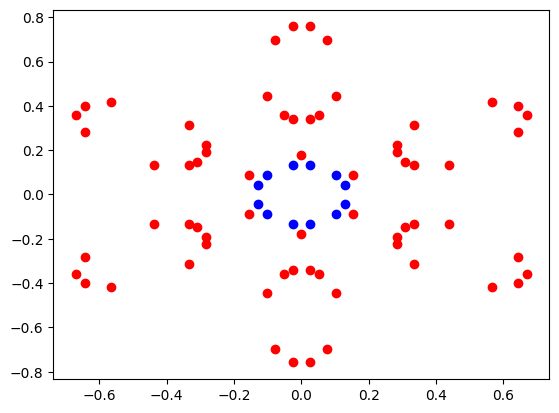

In [86]:
import numpy as np
import matplotlib.pyplot as plt


DATA_FILE_1 = "31-SPINTEXTURE_2D_GAMMA_CENTER.dat"
DATA_FILE_2 = "32-SPINTEXTURE_2D_GAMMA_CENTER.dat"

COLS = dict(kx=0, ky=1, E=2, Sx=3, Sy=4, Sz=5)

E0 = -2.1      # basis energy (eV)
dE = 0.01     # half-width of energy window (eV)
K_square = 0.2
dk = 0.1

def load_data(filepath):
    """Load a whitespace/comma-separated 6-column data file."""
    data = np.loadtxt(filepath, delimiter=None)
    return {
        "kx": data[:, COLS["kx"]],
        "ky": data[:, COLS["ky"]],
        "E": data[:, COLS["E"]],
        "Sx": data[:, COLS["Sx"]],
        "Sy": data[:, COLS["Sy"]],
        "Sz": data[:, COLS["Sz"]],
    }


def mask_energy_window(d, E0, dE):
    """Return only the entries with E in [E0 - dE, E0 + dE]."""
    mask = (d["E"] >= E0 - dE) & (d["E"] <= E0 + dE) 
    filtered = {key: val[mask] for key, val in d.items()}
    if len(filtered["E"]) == 0:
        raise ValueError(
            f"No points found in energy window [{E0-dE:.4f}, {E0+dE:.4f}] eV. "
            f"Data E range is [{d['E'].min():.4f}, {d['E'].max():.4f}] eV. "
            f"Adjust E0/dE."
        )
    return filtered


d1 = load_data(DATA_FILE_1)
d1_masked = mask_energy_window(d1,E0,dE)
d2 = load_data(DATA_FILE_2)
d2_masked = mask_energy_window(d2,E0,dE)

plt.scatter(d1_masked["kx"],d1_masked["ky"],color="red")
plt.scatter(d2_masked["kx"],d2_masked["ky"],color="blue")

Dataset 1: 18 points kept (out of 3600) in radius window [0.0900, 0.1100]
Dataset 2: 18 points kept (out of 3600) in radius window [0.0900, 0.1100]


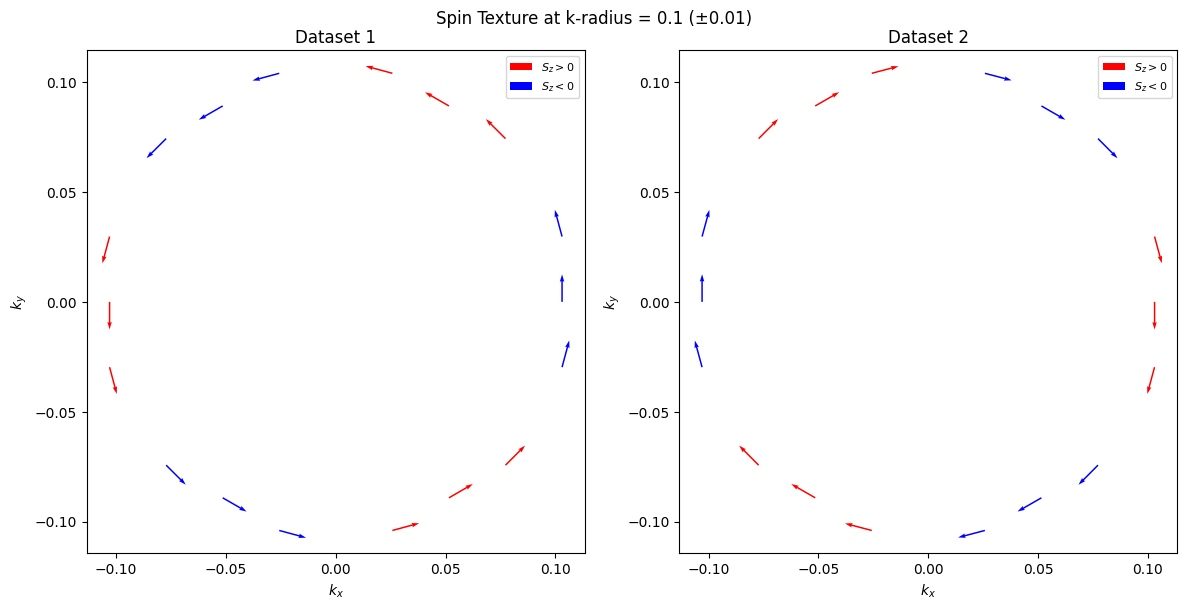

In [2]:
"""
Spin texture plotter for two datasets (e.g., two W-shaped bands above E_F).

Each data file must be plain text / whitespace- or comma-separated with 6 columns:
    k_x   k_y   E   S_x   S_y   S_z

Workflow:
    1. Load both datasets.
    2. Mask each dataset to keep only points where sqrt(kx^2 + ky^2) is
       approximately equal to a fixed k-radius (within a tolerance dK).
    3. Plot in-plane spin texture (S_x, S_y) as quiver arrows, colored by the
       SIGN of S_z only (two colors: one for S_z > 0, one for S_z < 0).

Edit the CONFIG block below to point to your files and set K_RADIUS / dK.
"""

import numpy as np
import matplotlib.pyplot as plt

# =========================== CONFIG ===========================
# Path to your two data files
DATA_FILE_1 = "31-SPINTEXTURE_2D_GAMMA_CENTER.dat"
DATA_FILE_2 = "32-SPINTEXTURE_2D_GAMMA_CENTER.dat"

# Radius window: keep points with |sqrt(kx^2 + ky^2) - K_RADIUS| <= dK
K_RADIUS = 0.1    # target k-radius (in same units as kx, ky)
dK = 0.01         # half-width of the radius window

# Column indices (0-indexed) in the data files: kx, ky, E, Sx, Sy, Sz
COLS = dict(kx=0, ky=1, E=2, Sx=3, Sy=4, Sz=5)

# Colors for S_z sign
COLOR_SZ_POS = "red"
COLOR_SZ_NEG = "blue"

# Quiver appearance
ARROW_SCALE = None      # None = matplotlib auto-scales; set a number to fix arrow length
ARROW_WIDTH = 0.003

# Titles for the two subplots
TITLE_1 = "Dataset 1"
TITLE_2 = "Dataset 2"

# Output figure filename
OUTPUT_FIGURE = "spin_texture.png"
# ================================================================


def load_data(filepath):
    """Load a whitespace/comma-separated 6-column data file."""
    data = np.loadtxt(filepath, delimiter=None)
    return {
        "kx": data[:, COLS["kx"]],
        "ky": data[:, COLS["ky"]],
        "E": data[:, COLS["E"]],
        "Sx": data[:, COLS["Sx"]],
        "Sy": data[:, COLS["Sy"]],
        "Sz": data[:, COLS["Sz"]],
    }


def mask_k_radius(d, k_radius, dk):
    """Return only the entries with sqrt(kx^2 + ky^2) in [k_radius - dk, k_radius + dk]."""
    k_mag = np.sqrt(d["kx"] ** 2 + d["ky"] ** 2)
    mask = (k_mag >= k_radius - dk) & (k_mag <= k_radius + dk)
    return {key: val[mask] for key, val in d.items()}


def plot_spin_texture(ax, d, title):
    """Quiver plot of (Sx, Sy) colored by sign of Sz."""
    pos = d["Sz"] >= 0
    neg = ~pos

    ax.quiver(
        d["kx"][pos], d["ky"][pos], d["Sx"][pos], d["Sy"][pos],
        color=COLOR_SZ_POS, scale=ARROW_SCALE, width=ARROW_WIDTH,
        label="$S_z > 0$",
    )
    ax.quiver(
        d["kx"][neg], d["ky"][neg], d["Sx"][neg], d["Sy"][neg],
        color=COLOR_SZ_NEG, scale=ARROW_SCALE, width=ARROW_WIDTH,
        label="$S_z < 0$",
    )

    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)


def main():
    d1 = load_data(DATA_FILE_1)
    d2 = load_data(DATA_FILE_2)

    d1_masked = mask_k_radius(d1, K_RADIUS, dK)
    d2_masked = mask_k_radius(d2, K_RADIUS, dK)

    print(f"Dataset 1: {len(d1_masked['kx'])} points kept "
          f"(out of {len(d1['kx'])}) in radius window [{K_RADIUS-dK:.4f}, {K_RADIUS+dK:.4f}]")
    print(f"Dataset 2: {len(d2_masked['kx'])} points kept "
          f"(out of {len(d2['kx'])}) in radius window [{K_RADIUS-dK:.4f}, {K_RADIUS+dK:.4f}]")

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    plot_spin_texture(axes[0], d1_masked, TITLE_1)
    plot_spin_texture(axes[1], d2_masked, TITLE_2)

    fig.suptitle(f"Spin Texture at k-radius = {K_RADIUS} (±{dK})")
    fig.tight_layout()
    #fig.savefig(OUTPUT_FIGURE, dpi=300)
    plt.show()


if __name__ == "__main__":
    main()

Dataset 1: 282 points kept (out of 3600) in window [-2.2500, -2.1500] eV
Dataset 2: 24 points kept (out of 3600) in window [-2.2500, -2.1500] eV
Dataset 1: circle radius = 0.51417, 12/282 points kept (tol = 0.005)
Dataset 2: circle radius = 0.10908, 12/24 points kept (tol = 0.005)


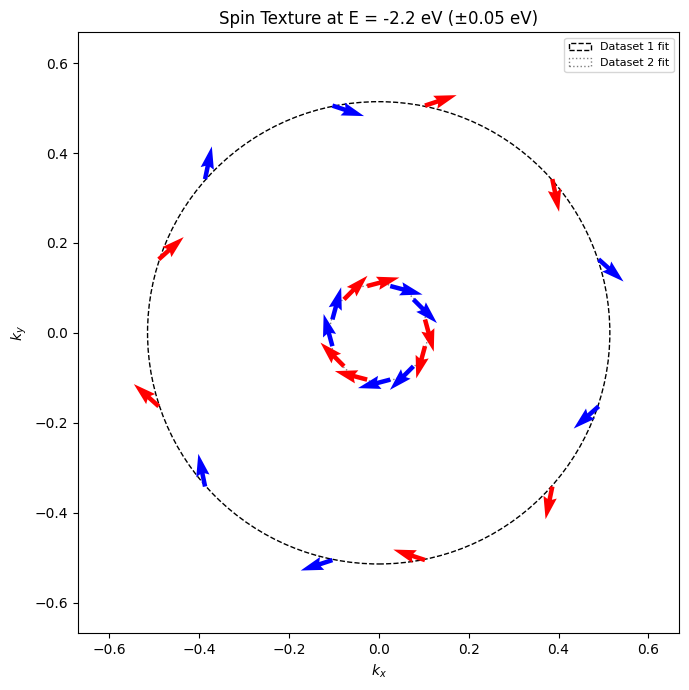

In [21]:
"""
Spin texture plotter for two datasets (e.g., two W-shaped bands above E_F).

Each data file must be plain text / whitespace- or comma-separated with 6 columns:
    k_x   k_y   E   S_x   S_y   S_z

Workflow:
    1. Load both datasets.
    2. Mask each dataset to keep only points with E in [E0 - dE, E0 + dE].
    3. From these energy-masked points, fit an "ideal" circle radius (the mean
       of sqrt(kx^2 + ky^2)), then keep only the points that actually lie
       close to that circle (within a tolerance CIRCLE_TOL) -- i.e. the
       points that "create" the circle. Points that are off the circle
       (e.g. stray points from a non-isotropic band) are discarded.
    4. Plot the in-plane spin texture (S_x, S_y) as quiver arrows -- only for
       the on-circle points -- colored by the SIGN of S_z only (two colors).
       Arrow vectors are normalized to a fixed length so both datasets are
       visually comparable regardless of their raw spin magnitudes.

Edit the CONFIG block below to point to your files and set E0 / dE / CIRCLE_TOL.
"""

import numpy as np
import matplotlib.pyplot as plt

# =========================== CONFIG ===========================
# Path to your two data files
DATA_FILE_1 = "31-SPINTEXTURE_2D_GAMMA_CENTER.dat"
DATA_FILE_2 = "32-SPINTEXTURE_2D_GAMMA_CENTER.dat"

# Energy window: keep points with E0 - dE <= E <= E0 + dE
E0 = -2.2     # basis energy (eV), e.g. 50 meV above E_F
dE = 0.05      # half-width of energy window (eV)

# Column indices (0-indexed) in the data files: kx, ky, E, Sx, Sy, Sz
COLS = dict(kx=0, ky=1, E=2, Sx=3, Sy=4, Sz=5)

# Colors for S_z sign
COLOR_SZ_POS = "red"
COLOR_SZ_NEG = "blue"

# Normalized arrow length (all arrows are rescaled to this length, in kx/ky units)
ARROW_LENGTH = None
ARROW_WIDTH = 0.003
ARROW_SCALE = 1.0   # matplotlib quiver scale; with normalized vectors, scale=1 and
                     # angles/scale_units="xy" makes arrow length == ARROW_LENGTH exactly

# Tolerance for keeping points close to the fitted ideal circle radius
# (points with | |k| - r_fit | > CIRCLE_TOL are discarded)
CIRCLE_TOL = 0.005

# Linestyle/marker to distinguish the two datasets' fitted circles
CIRCLE_STYLE_1 = dict(linestyle="--", edgecolor="black", label="Dataset 1 fit")
CIRCLE_STYLE_2 = dict(linestyle=":", edgecolor="gray", label="Dataset 2 fit")

# Labels for the two datasets (used in the legend)
LABEL_1 = "Dataset 1"
LABEL_2 = "Dataset 2"

# Title for the combined plot
TITLE = "Spin Texture"

# Output figure filename
OUTPUT_FIGURE = "spin_texture.png"
# ================================================================


def load_data(filepath):
    """Load a whitespace/comma-separated 6-column data file."""
    data = np.loadtxt(filepath, delimiter=None)
    return {
        "kx": data[:, COLS["kx"]],
        "ky": data[:, COLS["ky"]],
        "E": data[:, COLS["E"]],
        "Sx": data[:, COLS["Sx"]],
        "Sy": data[:, COLS["Sy"]],
        "Sz": data[:, COLS["Sz"]],
    }


def mask_energy_window(d, E0, dE):
    """Return only the entries with E in [E0 - dE, E0 + dE]."""
    mask = (d["E"] >= E0 - dE) & (d["E"] <= E0 + dE)
    return {key: val[mask] for key, val in d.items()}


def fit_ideal_circle_radius(d):
    """Estimate the 'ideal' constant-energy circle radius as the mean |k|."""
    k_mag = np.sqrt(d["kx"] ** 2 + d["ky"] ** 2)
    return k_mag.mean(), k_mag.std()


def mask_to_circle(d, tol):
    """
    Given energy-window-masked data, fit the ideal circle radius, then keep
    only the points whose |k| is within `tol` of that radius (i.e. the
    points that actually lie on the circle).

    Returns (filtered_data, radius).
    """
    r, _ = fit_ideal_circle_radius(d)
    k_mag = np.sqrt(d["kx"] ** 2 + d["ky"] ** 2)
    mask = np.abs(k_mag - r) <= tol
    filtered = {key: val[mask] for key, val in d.items()}
    return filtered, r


def plot_spin_texture(ax, d, alpha=1.0):
    """Quiver plot of normalized (Sx, Sy) colored by sign of Sz."""
    pos = d["Sz"] >= 0
    neg = ~pos

    Ux, Uy = d["Sx"], d["Sy"]

    ax.quiver(
        d["kx"][pos], d["ky"][pos], Ux[pos], Uy[pos],
        color=COLOR_SZ_POS
    )
    ax.quiver(
        d["kx"][neg], d["ky"][neg], Ux[neg], Uy[neg],
        color=COLOR_SZ_NEG
    )


def main():
    d1 = load_data(DATA_FILE_1)
    d2 = load_data(DATA_FILE_2)

    d1_masked = mask_energy_window(d1, E0, dE)
    d2_masked = mask_energy_window(d2, E0, dE)

    print(f"Dataset 1: {len(d1_masked['E'])} points kept "
          f"(out of {len(d1['E'])}) in window [{E0-dE:.4f}, {E0+dE:.4f}] eV")
    print(f"Dataset 2: {len(d2_masked['E'])} points kept "
          f"(out of {len(d2['E'])}) in window [{E0-dE:.4f}, {E0+dE:.4f}] eV")

    # Refine down to only the points that actually lie on the ideal circle
    d1_circle, r1 = mask_to_circle(d1_masked, CIRCLE_TOL)
    d2_circle, r2 = mask_to_circle(d2_masked, CIRCLE_TOL)

    print(f"Dataset 1: circle radius = {r1:.5f}, "
          f"{len(d1_circle['kx'])}/{len(d1_masked['kx'])} points kept (tol = {CIRCLE_TOL})")
    print(f"Dataset 2: circle radius = {r2:.5f}, "
          f"{len(d2_circle['kx'])}/{len(d2_masked['kx'])} points kept (tol = {CIRCLE_TOL})")

    fig, ax = plt.subplots(figsize=(7, 7))

    # Reference circles (ideal constant-|k| contours)
    circle1 = plt.Circle((0, 0), r1, fill=False, **CIRCLE_STYLE_1)
    circle2 = plt.Circle((0, 0), r2, fill=False, **CIRCLE_STYLE_2)
    ax.add_patch(circle1)
    ax.add_patch(circle2)

    # Spin texture arrows -- only for points that lie on the fitted circle
    plot_spin_texture(ax, d1_circle, alpha=1.0)
    plot_spin_texture(ax, d2_circle, alpha=0.6)

    max_r = max(r1, r2) * 1.3
    ax.set_xlim(-max_r, max_r)
    ax.set_ylim(-max_r, max_r)
    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)

    ax.set_title(f"{TITLE} at E = {E0} eV (±{dE} eV)")
    fig.tight_layout()
    #fig.savefig(OUTPUT_FIGURE, dpi=300)
    plt.show()


if __name__ == "__main__":
    main()

In [8]:
import numpy as np

def read_poscar(filename="relaxed-POSCAR"):
    with open(filename, "r") as f:
        lines = f.readlines()

    scale = float(lines[1].strip())
    a_vec = [float(x) for x in lines[2].split()]
    b_vec = [float(x) for x in lines[3].split()]
    c_vec = [float(x) for x in lines[4].split()]
    species_line = lines[5].strip()
    counts_line  = lines[6].strip()
    coord_type   = lines[7].strip()
    atom_coords  = [lines[i].strip() for i in range(8, len(lines)) if lines[i].strip()]

    return scale, a_vec, b_vec, c_vec, species_line, counts_line, coord_type, atom_coords

strain_list = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16, 18]

scale, a_vec, b_vec, c_vec, species_line, counts_line, coord_type, atom_coords = read_poscar()

for i in strain_list:
    factor = 1 + i / 100

    # Only scale the in-plane (x, y) components; leave z untouched
    def strain_vec(v):
        return [v[0] * factor, v[1] * factor, v[2]]

    a_s = strain_vec(a_vec)
    b_s = strain_vec(b_vec)
    c_s = strain_vec(c_vec)

    filename = f"POSCAR-{i}"
    content = (
        f"Buckled BiAs strained {i}%\n"
        f"   {scale:.14f}\n"
        f"\t{a_s[0]:.15f}\t{a_s[1]:.15f}\t{a_s[2]:.15f}\n"
        f"\t{b_s[0]:.15f}\t{b_s[1]:.15f}\t{b_s[2]:.15f}\n"
        f"\t{c_s[0]:.15f}\t{c_s[1]:.15f}\t{c_s[2]:.15f}\n"
        f"   {species_line}\n"
        f"    {counts_line}\n"
        f"{coord_type}\n"
    )
    for coord in atom_coords:
        content += f"\t{coord}\n"

    with open(filename, "w") as f:
        f.write(content)

    print(f"Written: {filename}")

Written: POSCAR-2
Written: POSCAR-4
Written: POSCAR-6
Written: POSCAR-8
Written: POSCAR-10
Written: POSCAR-11
Written: POSCAR-12
Written: POSCAR-13
Written: POSCAR-14
Written: POSCAR-16
Written: POSCAR-18


[0.0, 1.02, 1.903, 2.413, 3.432]
[0.0, 1.0, 1.866, 2.366, 3.366]
[0.0, 0.981, 1.831, 2.322, 3.303]
[0.0, 0.963, 1.797, 2.279, 3.242]
[0.0, 0.946, 1.764, 2.237, 3.183]
[0.0, 0.937, 1.748, 2.217, 3.154]
[0.0, 0.929, 1.733, 2.197, 3.126]
[0.0, 0.92, 1.718, 2.178, 3.098]
[0.0, 0.912, 1.702, 2.159, 3.071]
[0.0, 0.897, 1.673, 2.121, 3.018]


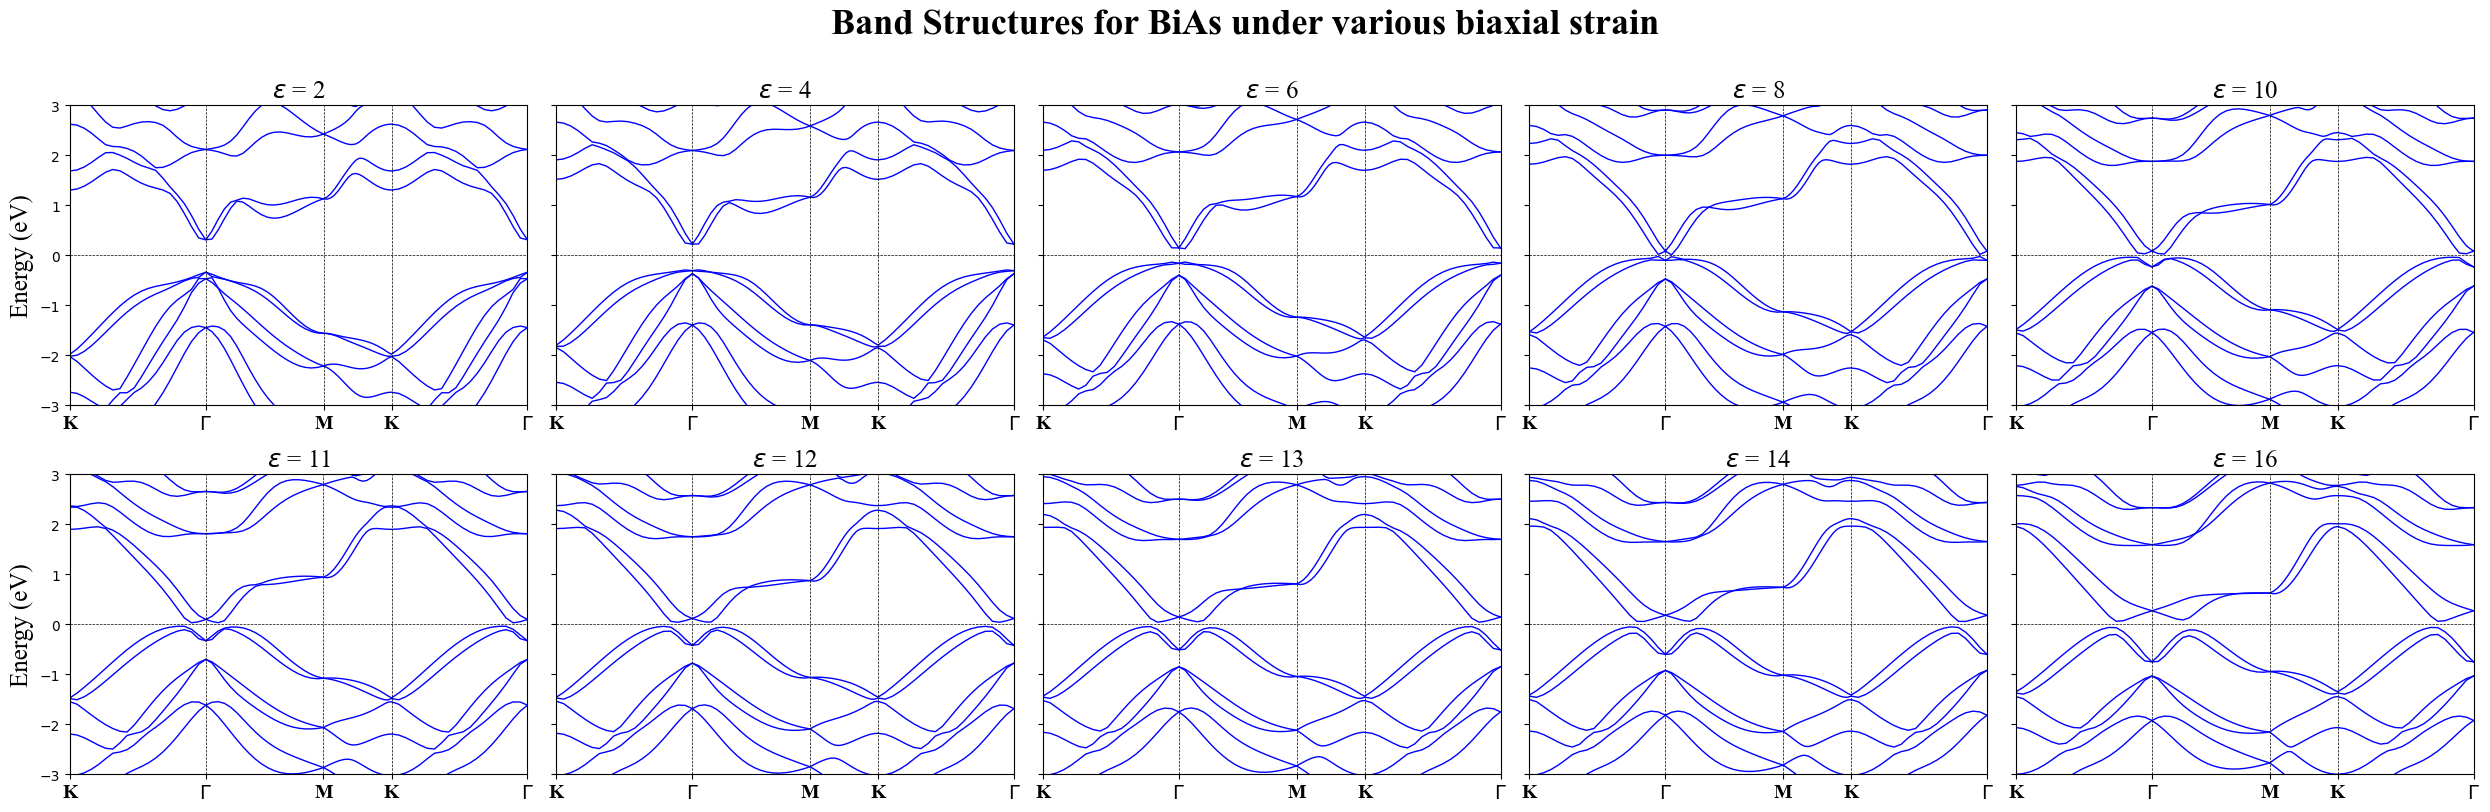

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Config ---
file_indices = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]
high_symmetry_points = [0, 0.780, 1.456, 1.846, 2.626]
high_sym_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

# --- Load all datasets ---
datasets = {i: np.loadtxt(f"{i}-REFORMATTED_BAND.dat") for i in file_indices}

# --- Layout: 4 cols, enough rows to fit all ---
n_plots = len(file_indices)
n_cols = 5
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                          sharey=True)
axes = axes.flatten()

def read_klabels(filename):
    """
    Parse a KLABELS file and return the list of k-path positions.
    Skips the header line and any empty lines.
    """
    points = []
    with open(filename, 'r') as f:
        lines = f.readlines()
    # Skip header (first line), read lines with two columns
    for line in lines[1:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) == 2:
            try:
                points.append(float(parts[1]))
            except ValueError:
                continue
    return points

for ax, (idx, data) in zip(axes, datasets.items()):
    k = data[:, 0]
    bands = data[:, 1:]
    high_sym_points = read_klabels(f"labels/{idx}-KLABELS")
    print(high_sym_points)
    for i in range(bands.shape[1]):
        ax.plot(k, bands[:, i], color='blue', linewidth=1, label='DFT' if i == 0 else "")

    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax.set_xlim(k.min(), k.max())

    for i in range(len(high_sym_points)):
        ax.axvline(high_sym_points[i],lw=0.5,ls="--",color='black')

    ax.set_ylim(-3, 3)
    ax.set_xticks(high_sym_points)
    ax.set_xticklabels(high_sym_labels, fontsize=14, fontname="Times New Roman",fontweight="bold")
    ax.set_title(rf'$\epsilon$ = {idx}',fontsize=18, fontname="Times New Roman")

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('Energy (eV)', fontsize=18, fontname="Times New Roman")

# Hide any unused subplots
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle('Band Structures for BiAs under various biaxial strain', fontsize=26, fontname="Times New Roman",fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2026-06-12 12:48:33,856                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(30, 101, 5)                                |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

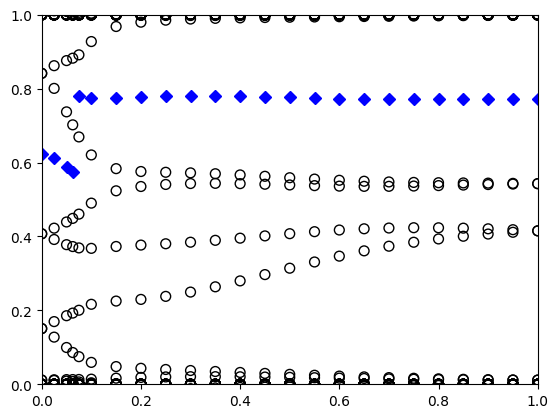

In [2]:
import z2pack
import tbmodels # type: ignore
import matplotlib.pyplot as plt

model = tbmodels.Model.from_wannier_files(hr_file='12-wannier90_hr.dat', wsvec_file='12-wannier90_wsvec.dat',occ=30)

system = z2pack.tb.System(model)
result = z2pack.surface.run(system=system, surface=lambda t1,t2: [t1/2, t2, 0.0],num_lines=21,iterator=range(30, 101, 5))

z2pack.plot.wcc(result)
print(z2pack.invariant.z2(result))
plt.show()

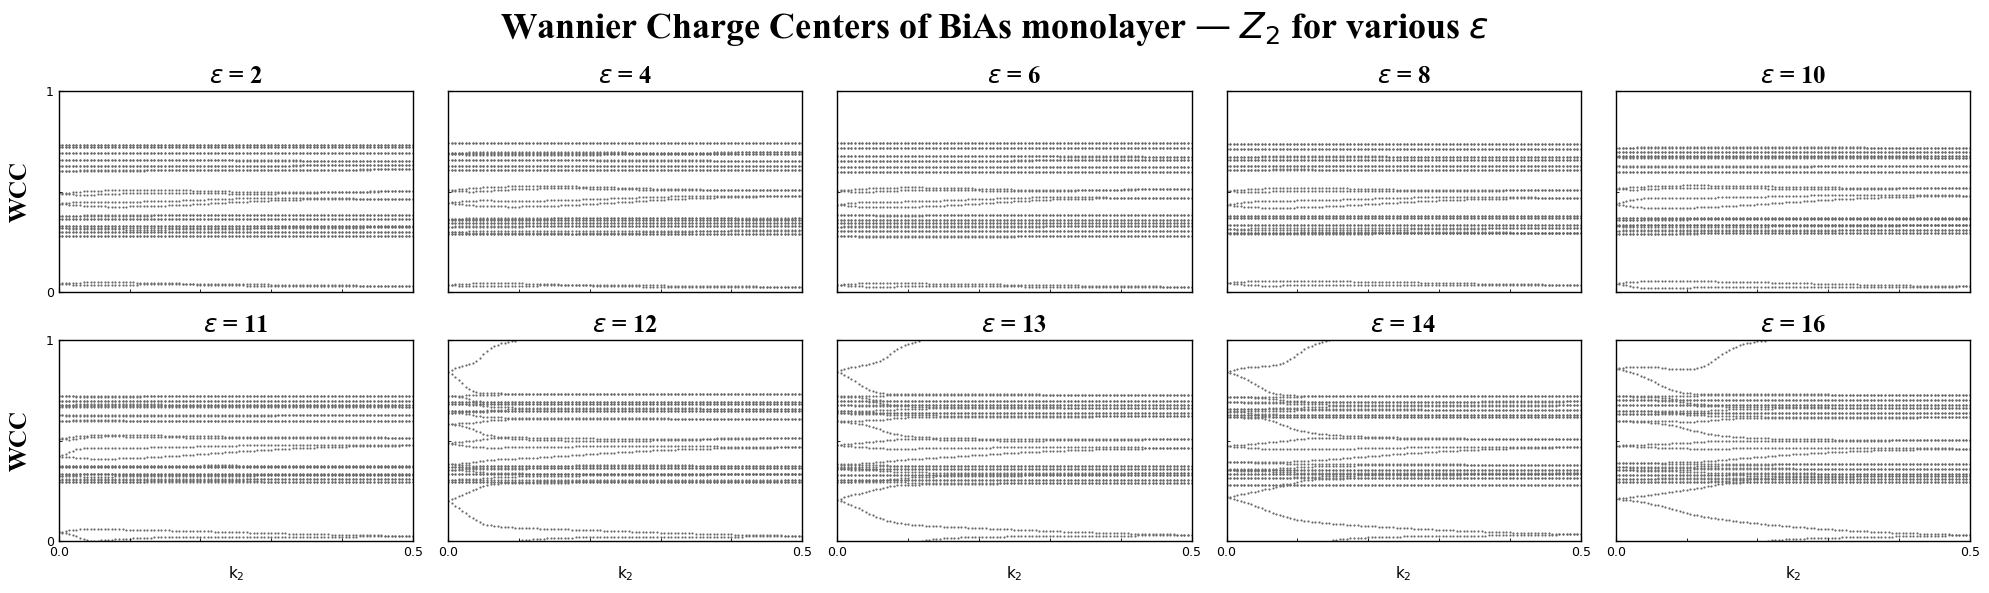

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Config ---
LCOLOR = '#696969'
file_indices = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]

n_plots = len(file_indices)
n_cols = 5
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, idx in zip(axes, file_indices):
    try:
        data = np.loadtxt(f"{idx}-wanniercenter3D_Z2_6.dat")
        ax.scatter(data[:, 0] / 2, data[:, 1],
                   s=2.5, color=LCOLOR, marker='o', linewidths=0)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'e{idx} not found',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)

    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.tick_params(axis='x', which='both', direction='in', labelsize=9)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%1.0f'))
    ax.tick_params(axis='y', which='both', direction='in', labelsize=9)

    ax.set_title(rf'$\epsilon$ = {idx}', fontname="Times New Roman",fontweight="bold",fontsize=18)

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('WCC', rotation=90, fontname="Times New Roman",fontweight="bold", fontsize=18, labelpad=10)
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel(r'k$_2$', fontsize=11)

    for spine in ax.spines.values():
        spine.set_linewidth(1)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle(r'Wannier Charge Centers of BiAs monolayer — $Z_2$ for various $\epsilon$', fontname="Times New Roman",fontweight="bold",fontsize=26)
plt.tight_layout()
plt.savefig("wannier_centers_comparison.png", dpi=300)
plt.show()

Global DOS range: [1.5324599, 7.2920746]


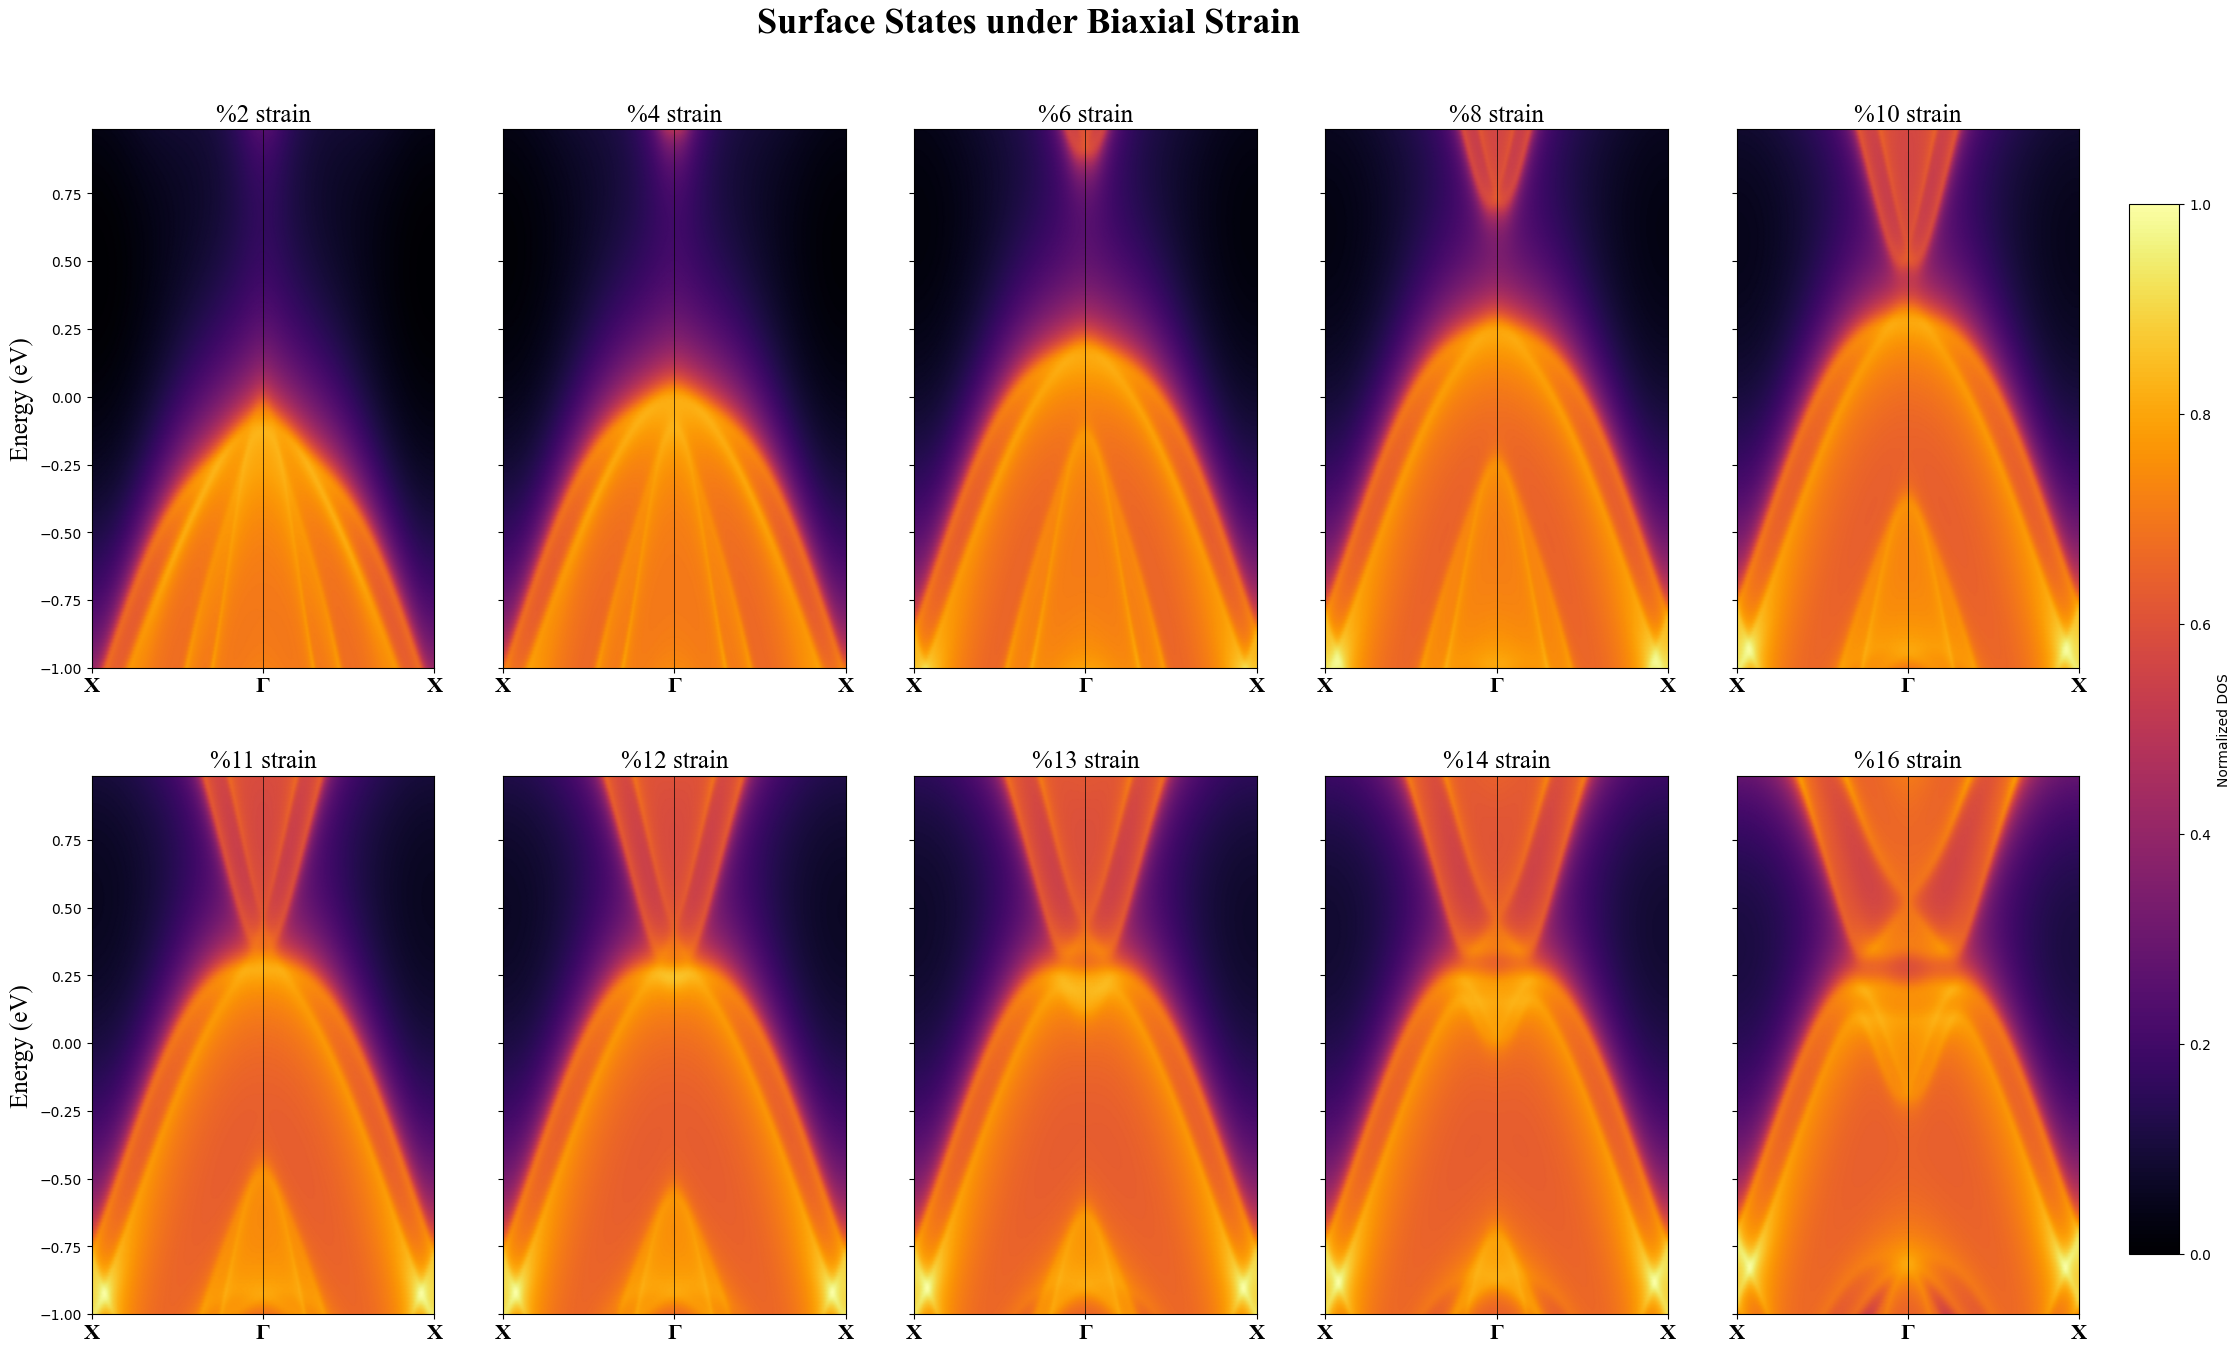

Plot displayed!


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import griddata

# Loading all data
data_2 = np.loadtxt("2-dos.dat_bulk")
data_4 = np.loadtxt("4-dos.dat_bulk")
data_6 = np.loadtxt("6-dos.dat_bulk")
data_8 = np.loadtxt("8-dos.dat_bulk")
data_10 = np.loadtxt("10-dos.dat_bulk")
data_11 = np.loadtxt("11-dos.dat_bulk")
data_12 = np.loadtxt("12-dos.dat_bulk")
data_13 = np.loadtxt("13-dos.dat_bulk")
data_14 = np.loadtxt("14-dos.dat_bulk")
data_16 = np.loadtxt("16-dos.dat_bulk")

# Collect all datasets
datasets = [data_2, data_4, data_6, data_8, data_10, data_11, data_12, data_13, data_14, data_16]
labels = ['2', '4', '6', '8', '10', '11', '12', '13', '14', '16']

# Find global min and max of DOS values across all datasets
global_min = min(data[:, 2].min() for data in datasets)
global_max = max(data[:, 2].max() for data in datasets)

print(f"Global DOS range: [{global_min}, {global_max}]")

# Normalize all datasets to [0, 1] range
normalized_datasets = []
for data in datasets:
    data_normalized = data.copy()
    # Min-max normalization
    data_normalized[:, 2] = (data[:, 2] - global_min) / (global_max - global_min)
    normalized_datasets.append(data_normalized)

from matplotlib.colors import LinearSegmentedColormap

# Define custom black-white-yellow colormap
colors = ['#000000', '#FFFFFF', "#FFAE00"]
n_bins = 256  # Discretizes the interpolation into bins
cmap_custom = LinearSegmentedColormap.from_list('black_white_yellow', colors, N=n_bins)

# Function to plot a single dataset
def plot_dos(data, title_suffix, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    x = data[:, 0]
    y = data[:, 1]
    z = data[:, 2]  # Already normalized, no exponential needed
    
    # Create interpolated grid for smooth plotting
    xi = np.linspace(x.min(), x.max(), 400)
    yi = np.linspace(y.min(), y.max(), 400)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), z, (Xi, Yi), method='cubic')
    
    # Plot the data
    im = ax.pcolormesh(Xi, Yi, Zi, cmap="inferno", shading='gouraud', 
                       vmin=0, vmax=1)  # Fixed scale [0, 1]
    
    # Set axis limits
    ax.set_xlim(min(x), max(x))
    
    # Set x-axis ticks and labels
    ax.set_xticks([min(x), (min(x)+max(x))/2, max(x)])
    ax.set_xticklabels(['X', 'Γ', 'X'],fontname="Times New Roman", fontweight="bold",fontsize=16)
    
    
    # Add vertical line at Gamma point
    ax.axvline(x=(min(x)+max(x))/2, color='black', linewidth=0.5)

    ax.set_title(f"%{title_suffix} strain",fontname="Times New Roman", fontsize=18)

    return im

# Create a comparison plot with all datasets
fig, axes = plt.subplots(2, 5, figsize=(25, 15),sharey=True)
axes = axes.flatten()

for i, (data, label) in enumerate(zip(normalized_datasets, labels)):
    im = plot_dos(data, label, axes[i])
    if i == 0 or i == 5:
        axes[i].set_ylabel('Energy (eV)', fontname="Times New Roman", fontsize=18)
# Adjust subplot spacing to make room for colorbar on the right
fig.subplots_adjust(right=0.92, top=0.90)  # Added top spacing for title

# Add overall title at the top
fig.suptitle("Surface States under Biaxial Strain", fontname="Times New Roman", fontweight="bold",fontsize=26, y=0.98)

# Add a shared colorbar on the far right
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='Normalized DOS')
plt.savefig("surface_states_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot displayed!")

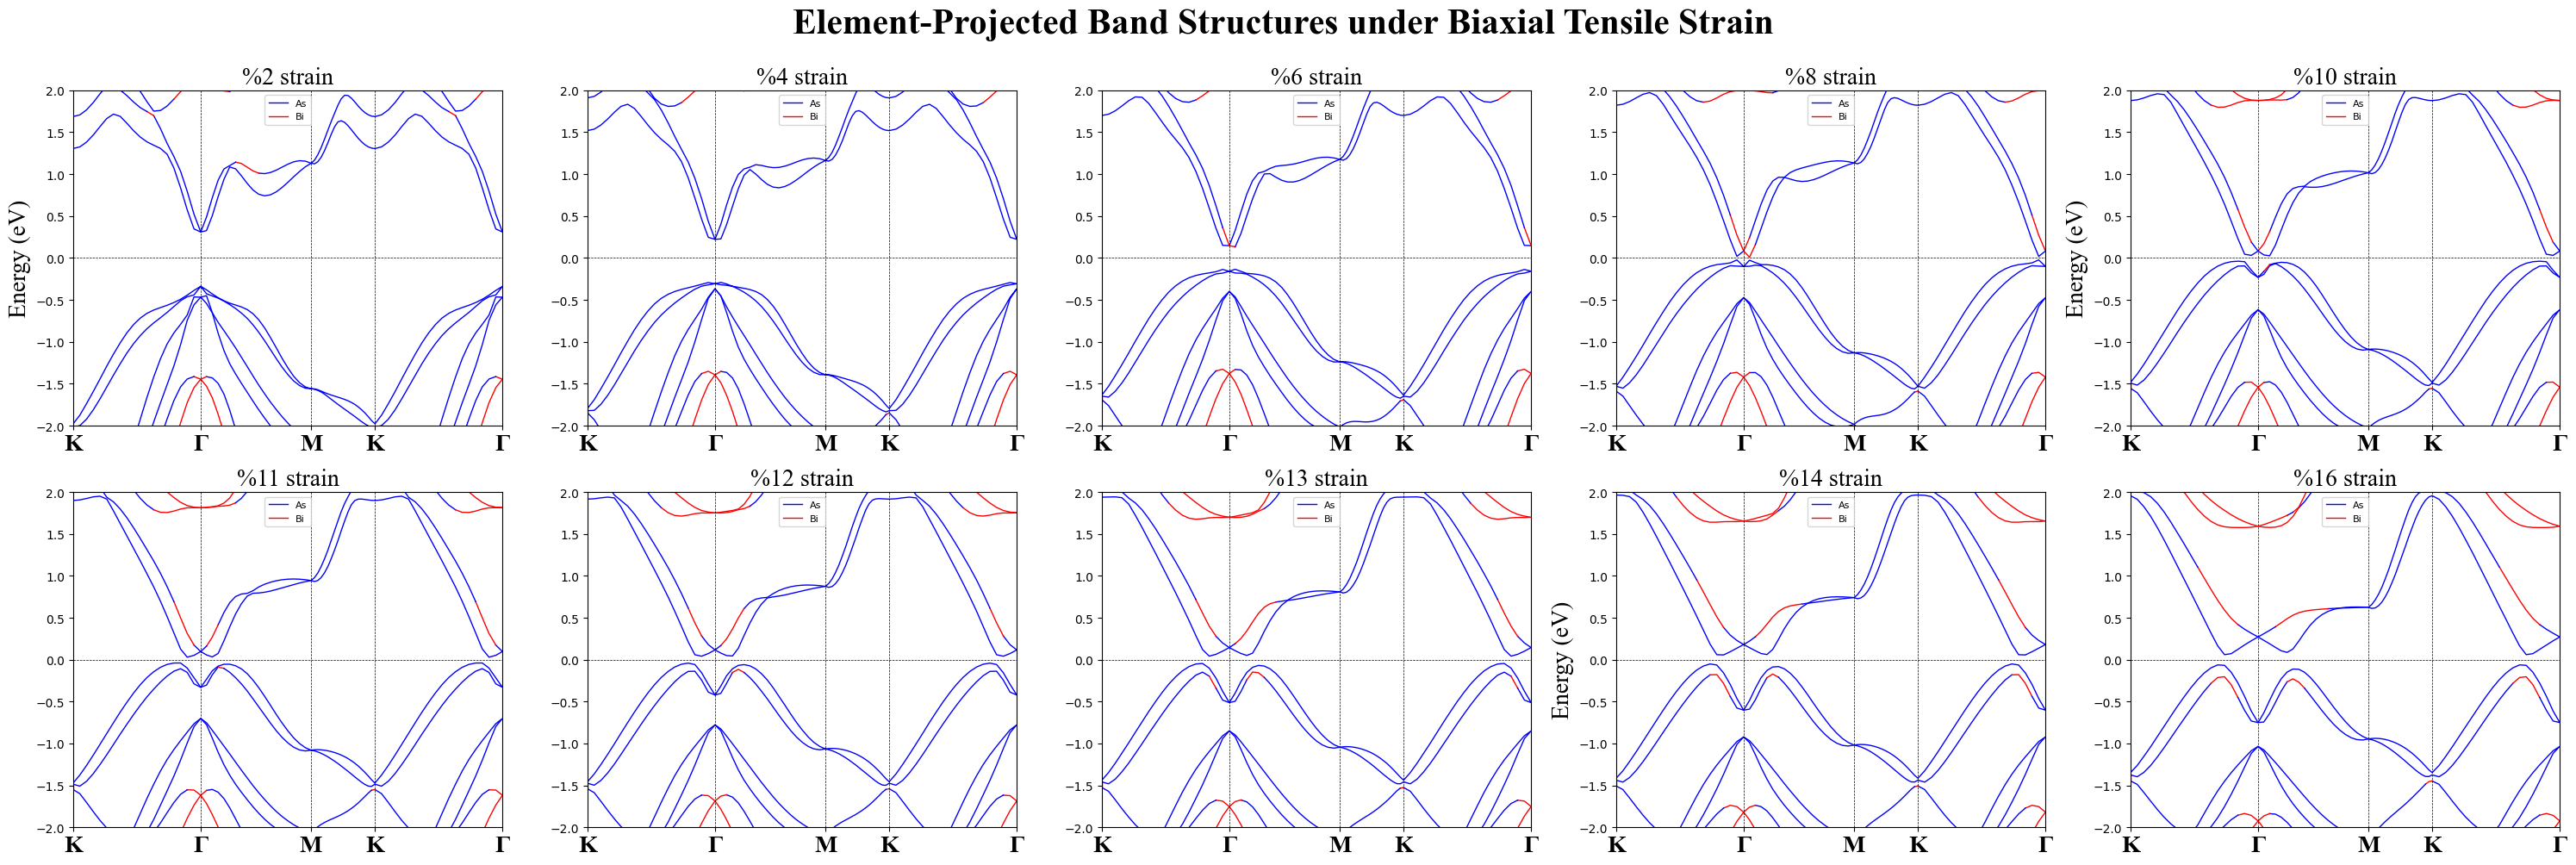

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Load all datasets
data_2 = np.loadtxt("2-PBAND_ELEMENTS_SOC.dat")
data_4 = np.loadtxt("4-PBAND_ELEMENTS_SOC.dat")
data_6 = np.loadtxt("6-PBAND_ELEMENTS_SOC.dat")
data_8 = np.loadtxt("8-PBAND_ELEMENTS_SOC.dat")
data_10 = np.loadtxt("10-PBAND_ELEMENTS_SOC.dat")
data_11 = np.loadtxt("11-PBAND_ELEMENTS_SOC.dat")
data_12 = np.loadtxt("12-PBAND_ELEMENTS_SOC.dat")
data_13 = np.loadtxt("13-PBAND_ELEMENTS_SOC.dat")
data_14 = np.loadtxt("14-PBAND_ELEMENTS_SOC.dat")
data_16 = np.loadtxt("16-PBAND_ELEMENTS_SOC.dat")

# Collect all datasets
datasets = [data_2, data_4, data_6, data_8, data_10, data_12, data_14, data_16]

def read_klabels(filename):
    """
    Parse a KLABELS file and return the list of k-path positions.
    Skips the header line and any empty lines.
    """
    points = []
    with open(filename, 'r') as f:
        lines = f.readlines()
    # Skip header (first line), read lines with two columns
    for line in lines[1:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) == 2:
            try:
                points.append(float(parts[1]))
            except ValueError:
                continue
    return points

# Collect all datasets and their corresponding KLABELS files
labels = ['2', '4', '6', '8','10', '11' ,'12', '13' ,'14', '16']

datasets = []
klabels_list = []
for label in labels:
    datasets.append(np.loadtxt(f"{label}-PBAND_ELEMENTS_SOC.dat"))
    klabels_list.append(read_klabels(f"labels/{label}-KLABELS"))

# Define elements and their corresponding columns
element_names = ['Bi', 'As']
element_columns = [2, 3]
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

high_sym_labels = ['K', 'Γ', 'M', 'K' ,'Γ']

# Create figure with subplots
fig, axes = plt.subplots(2,5, figsize=(30, 10))
axes = axes.flatten()

for idx, (elemented_data, label, sym_points) in enumerate(zip(datasets, labels, klabels_list)):
    ax = axes[idx]

    # Find dominant element at each k-point
    dominant_elements = np.argmax(elemented_data[:, element_columns], axis=1)

    color_changes = np.diff(dominant_elements)
    change_indices = np.where(color_changes != 0)[0] + 1
    segment_indices = np.concatenate(([0], change_indices, [len(elemented_data)]))

    labeled_elements = set()

    for i in range(len(segment_indices) - 1):
        start = segment_indices[i]
        end = segment_indices[i + 1]

        dominant_idx = dominant_elements[start]
        color = colors[dominant_idx]
        elem_label = element_names[dominant_idx]

        if elem_label not in labeled_elements:
            ax.plot(elemented_data[start:end+1, 0], elemented_data[start:end+1, 1],
                    color=color, label=elem_label, linewidth=1)
            labeled_elements.add(elem_label)
        else:
            ax.plot(elemented_data[start:end+1, 0], elemented_data[start:end+1, 1],
                    color=color, linewidth=1)

    for point in sym_points:
        ax.axvline(point,lw=0.5,color='black',ls='--')

    ax.axhline(0,lw=0.5,color='black',ls='--')

    ax.set_xticks(sym_points)
    ax.set_xticklabels(high_sym_labels,fontname="Times New Roman",fontweight="bold",fontsize=20)
    ax.set_xlim(min(elemented_data[:, 0]), max(elemented_data[:, 0]))
    ax.set_ylim(-2, 2)
    ax.set_title(f'%{label} strain',fontsize=20,fontname="Times New Roman")
    if idx == 0 or idx == 4 or idx ==8:
        ax.set_ylabel('Energy (eV)',fontsize=20,fontname="Times New Roman")
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.suptitle("Element-Projected Band Structures under Biaxial Tensile Strain ",
            fontsize=30,fontname="Times New Roman", fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

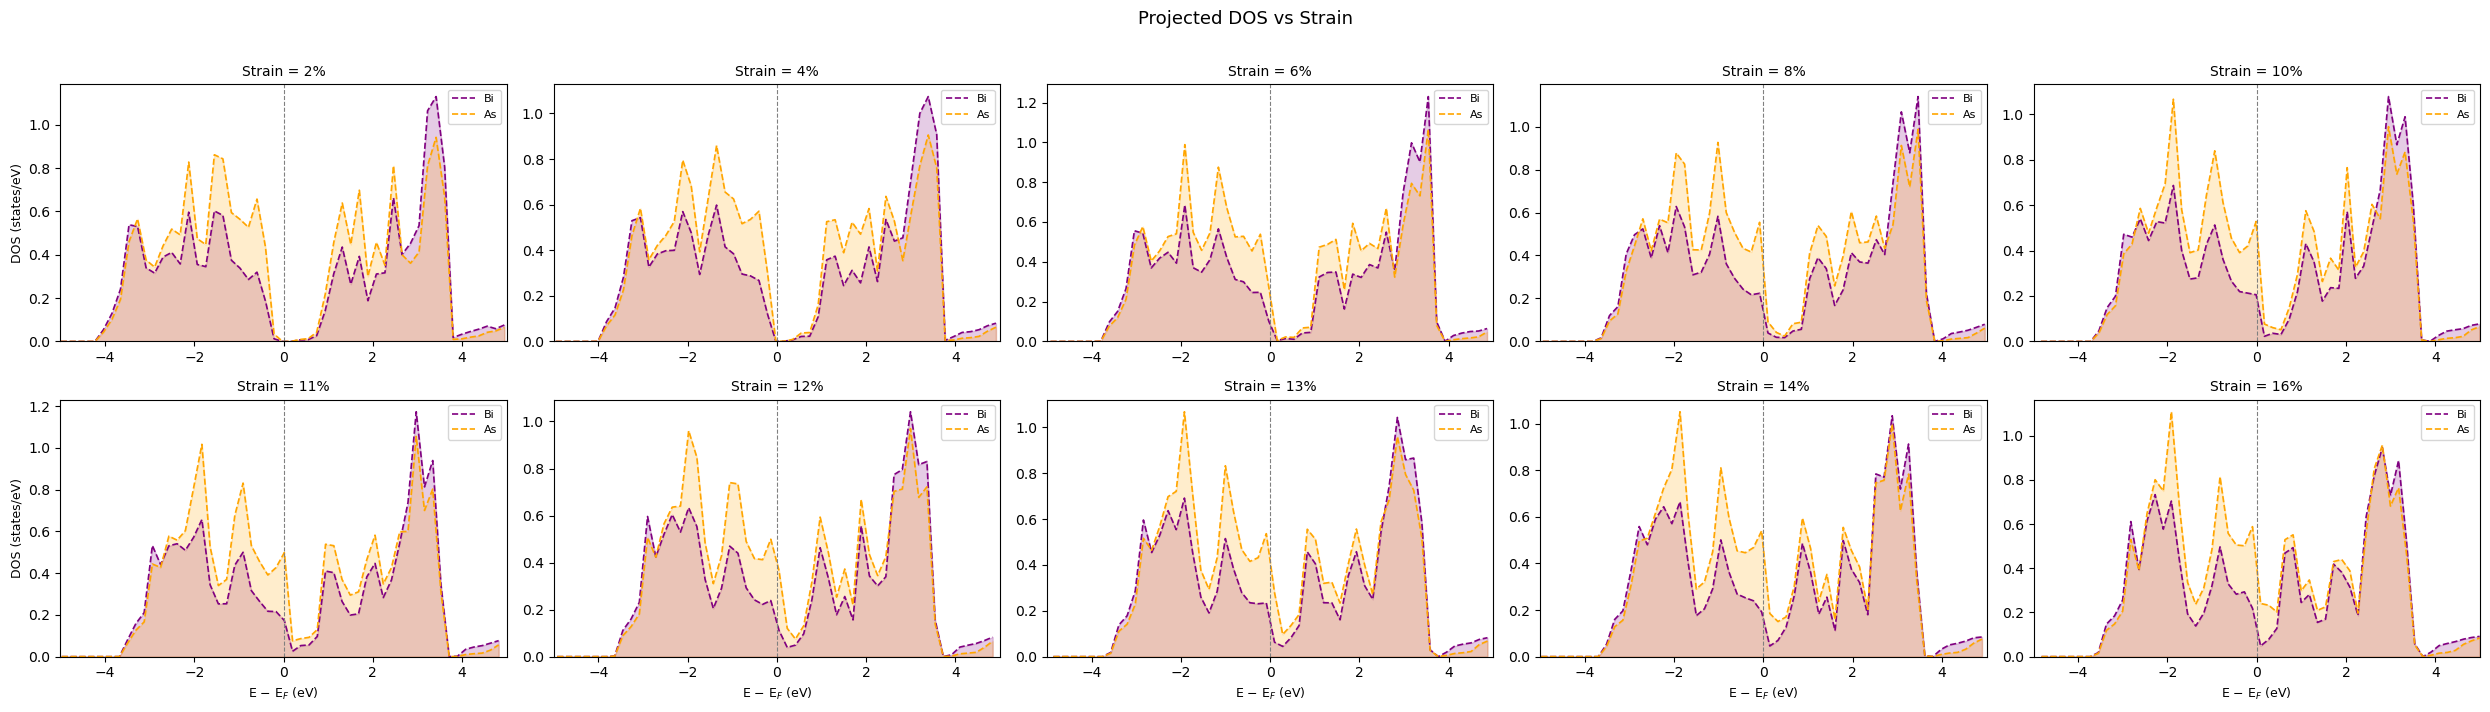

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

strains = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]

e_min, e_max = -5.0, 5.0

n = len(strains)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=False)
axes = axes.flatten()

for i, strain in enumerate(strains):
    ax = axes[i]

    # Load Bi and Sb PDOS
    bi_data = np.loadtxt(f'{strain}-PDOS_Bi_SOC.dat', unpack=True)
    sb_data = np.loadtxt(f'{strain}-PDOS_As_SOC.dat', unpack=True)

    energy = bi_data[0]
    tot_bi = bi_data[-1]   # last column = atom-summed total
    tot_sb = sb_data[-1]

    # Apply energy mask
    mask   = (energy >= e_min) & (energy <= e_max)
    energy = energy[mask]
    tot_bi = tot_bi[mask]
    tot_sb = tot_sb[mask]

    # Plot
    ax.plot(energy, tot_bi, label='Bi', color='purple', lw=1.2,ls = '--')
    ax.plot(energy, tot_sb, label='As', color='orange',  lw=1.2,ls = '--')
    ax.fill_between(energy, tot_bi, alpha=0.2, color='purple')
    ax.fill_between(energy, tot_sb, alpha=0.2, color='orange')

    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(e_min, e_max)
    ax.set_ylim(bottom=0)
    ax.set_title(f'Strain = {strain}%', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')

    # Only label outer axes
    if i % ncols == 0:
        ax.set_ylabel('DOS (states/eV)', fontsize=9)
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel('E − E$_F$ (eV)', fontsize=9)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Projected DOS vs Strain', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('DOS_all_strains.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\furka\AppData\Local\Temp\ipykernel_13620\1124661985.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='upper right')


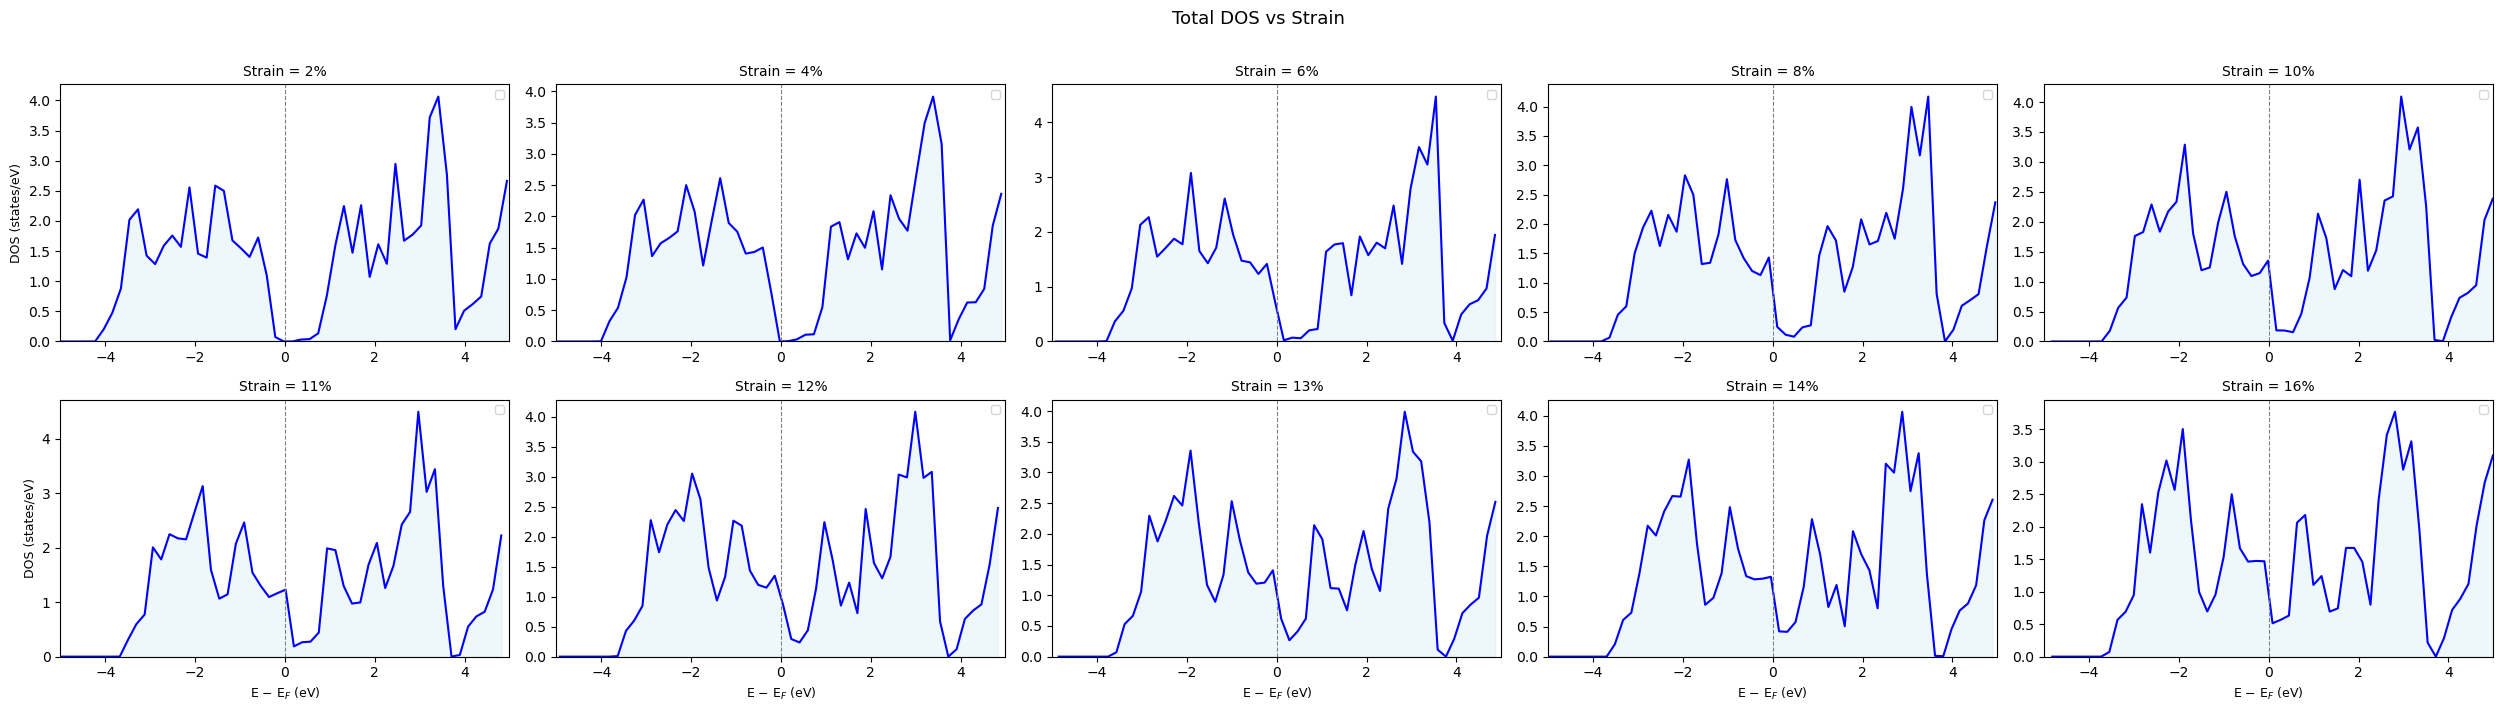

In [15]:
import numpy as np
import matplotlib.pyplot as plt

strains = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]

e_min, e_max = -5.0, 5.0

n = len(strains)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=False)
axes = axes.flatten()

for i, strain in enumerate(strains):
    ax = axes[i]

    # Load Bi and Sb PDOS
    data = np.loadtxt(f'{strain}-TDOS_SOC.dat', comments = '#')

    energy, dos = data.T

    mask   = (energy >= e_min) & (energy <= e_max)
    energy = energy[mask]
    dos = dos[mask]

    # Plot
    ax.plot(energy, dos, color='blue')
    ax.fill_between(energy, dos, alpha=0.2, color='lightblue')

    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(e_min, e_max)
    ax.set_ylim(bottom=0)
    ax.set_title(f'Strain = {strain}%', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')

    # Only label outer axes
    if i % ncols == 0:
        ax.set_ylabel('DOS (states/eV)', fontsize=9)
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel('E − E$_F$ (eV)', fontsize=9)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Total DOS vs Strain', fontsize=13, y=1.01)
plt.tight_layout()
#plt.savefig('DOS_all_strains.png', dpi=150, bbox_inches='tight')
plt.show()

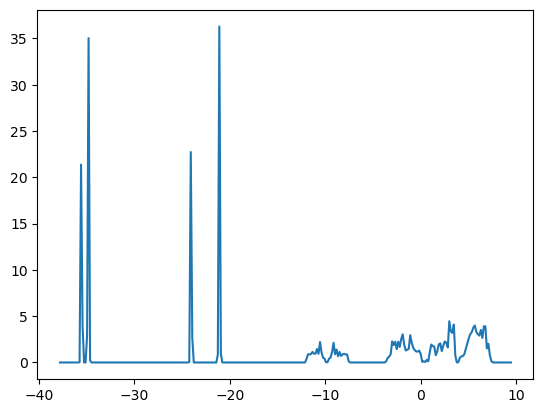

In [12]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("TDOS_SOC.dat",comments='#')
energy , dos = data.T
plt.plot(energy,dos)